
# **NBA Players' Statistics Analysis**

- Šime Jadrijev

Dataset: https://www.kaggle.com/datasets/justinas/nba-players-data



This project is used for two college courses:
- Introduction to Data Science
- Introduction to Data Science – Examples of Best Practices


**Project Overview:**


This notebook performs a comprehensive analysis of NBA players' statistics from 1996 to 2023, exploring various aspects of player performance, longevity, and career dynamics. It covers data cleaning and preprocessing, examines basic statistical distributions, investigates the impact of physical attributes and age on performance, analyzes the influence of draft position, and explores the role of college and nationality. The project also delves into predicting player longevity, comparing individual player and team performances, and identifying dominant players and playmakers.



**Key Questions Addressed:**

- How are player statistics distributed across different physical attributes and age groups?
- What is the relationship between draft position, player longevity, and on-court performance?
- Do college affiliation or player nationality significantly impact career statistics?
- How can we identify players who have outperformed or underperformed relative to their draft expectations?
- Can we predict a player's career longevity based on their early-career performance?
- How do the career trajectories and performances of individual players and teams compare over time?

#Data cleaning

In [ ]:
!pip install pingouin

In [58]:
import warnings
warnings.filterwarnings("ignore")

# Data manipulation and basic utilities
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import geopandas as gpd

# Statistical analysis
import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.stats.anova as smsa
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro, levene, kruskal, mannwhitneyu
import pingouin as pg

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, silhouette_score, confusion_matrix
import shap
from imblearn.over_sampling import SMOTE

In [59]:
data = pd.read_csv('/content/sample_data/all_seasons.csv', index_col=0)
data.head()

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


The data consists of information about NBA players by season, with each row representing one season of a player.

The dataset includes basic information such as height, weight, nationality, college, and points scored, as well as more advanced statistics that indicate the player's efficiency in scoring, rebounding, and more.

## Variables overview
**player_name:** Name and surname of the player <br>
**team_abbreviation:** Name of the team the player played for (at the end of the season) <br>
**age:** Age of the player <br>
**player_height:** Height of the player <br>
**player_weight:** Weight of the player <br>
**college:** Name of the college the player attended <br>
**country:** Player's nationality <br>
**draft_year:** The year the player was drafted <br>
**draft_round:** The draft round the player was picked <br>
**draft_number:** The number at which the player was drafted <br>
**gp:** Games played throughout the season <br>
**pts:** Average number of points scored <br>
**reb:** Average number of rebounds grabbed <br>
**ast:** Average number of assists distributed <br>
**net_rating:** Team's point differential per 100 possessions while the player is on the court <br>
**oreb_pct:** Percentage of available offensive rebounds the player grabbed while he was on the floor <br>
**dreb_pct:** Percentage of available defensive rebounds the player grabbed while he was on the floor <br>
**usg_pct:** Percentage of team plays used by the player while he was on the floor $\left(\frac{\text{FGA} + \text{Possession Ending FTA} + \text{TO}}{\text{POSS}}\right)$ <br>
**ts_pct:** Measure of the player's true shooting efficiency that takes into account free throws, 2 and 3 point shots $\left(\frac{\text{PTS}}{2 \cdot (\text{FGA} + 0.44 \cdot \text{FTA})}\right)$ <br>

**ast_pct:** Percentage of teammate field goals the player assisted while he was on the floor <br>
**season:** NBA season <br>


In [60]:
print("Data shape:", data.shape, "\n")
print(data.dtypes)

Data shape: (12844, 21) 

player_name           object
team_abbreviation     object
age                  float64
player_height        float64
player_weight        float64
college               object
country               object
draft_year            object
draft_round           object
draft_number          object
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                object
dtype: object


We can notice that some data that should be numerical is not numerical, for example, all draft-related data and season data. We can print all the values in these columns to see if there is any reason for these data to be non-numerical.


In [61]:
print(data['draft_year'].unique())
print(data['draft_round'].unique())
print(data['draft_number'].unique())
print(data['season'].unique())

['1996' '1994' '1993' '1989' '1995' '1985' '1988' '1991' '1986' '1990'
 '1984' '1987' '1982' '1992' 'Undrafted' '1983' '1981' '1978' '1979'
 '1980' '1976' '1997' '1998' '1999' '2000' '2001' '2002' '2003' '2004'
 '2005' '2006' '2007' '2008' '2009' '2010' '2011' '1963' '2012' '2013'
 '2014' '2015' '2016' '2017' '2018' '2019' '2020' '2021' '2022']
['2' '1' 'Undrafted' '3' '4' '8' '6' '7' '0']
['42' '34' '12' '7' '22' '47' '30' '4' '1' '3' '11' '33' '26' '35' '17'
 '25' '28' '49' '23' '2' '15' '27' 'Undrafted' '37' '38' '13' '18' '9'
 '21' '43' '14' '10' '6' '57' '52' '32' '39' '46' '29' '16' '45' '20' '48'
 '5' '79' '41' '51' '36' '75' '56' '8' '24' '165' '40' '19' '58' '44'
 '139' '54' '127' '124' '50' '160' '63' '31' '69' '53' '55' '120' '87'
 '66' '82' '60' '59' '78' '0']
['1996-97' '1997-98' '1998-99' '1999-00' '2000-01' '2001-02' '2002-03'
 '2003-04' '2004-05' '2005-06' '2006-07' '2007-08' '2008-09' '2009-10'
 '2010-11' '2011-12' '2012-13' '2013-14' '2014-15' '2015-16' '2016-17'
 '20

The data is **not stored as numerical** because it doesn't contain exclusively numerical values. All players who didn't enter the NBA through the draft are recorded as **"Undrafted"**, and some even have a **"0"** recorded as their draft round and number. The issue with the seasons is slightly different, as the start year and end year of the season are recorded.

In [62]:
data[data['draft_number']== '0']

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
10651,Jeremy Pargo,GSW,34.0,187.96,99.336648,Gonzaga,USA,2009,0,0,...,8.3,1.0,2.7,2.4,0.024,0.048,0.268,0.557,0.308,2019-20
10791,Josh Magette,ORL,30.0,185.42,72.574720,Alabama Huntsville,USA,2012,0,0,...,1.5,0.8,0.6,2.4,0.022,0.128,0.226,0.378,0.238,2019-20
12266,Scotty Hopson,OKC,32.0,200.66,92.532768,Tennessee,USA,2011,0,0,...,4.0,1.0,1.0,-18.4,0.000,0.043,0.143,0.500,0.091,2021-22


A quick online check shows that players with a “0” recorded as their draft number were never actually drafted — supporting our hypothesis that both “Undrafted” and “0” denote the same thing. Our aim is to standardize those entries, since they represent the same status.

In [63]:
data['draft_round'] = data['draft_round'].replace('Undrafted', 0)
data['draft_number'] = data['draft_number'].replace('Undrafted', 0)
data['draft_year'] = data['draft_year'].replace('Undrafted', 0)

In [64]:
data['draft_year'] = pd.to_numeric(data['draft_year'], errors='coerce')
data['draft_round'] = pd.to_numeric(data['draft_round'], errors='coerce')
data['draft_number'] = pd.to_numeric(data['draft_number'], errors='coerce')

For the season, it's sufficient to have the start year recorded, as all seasons last the same period of time.

In [65]:
data['season'] = data['season'].str.split('-').str[0].astype(int)

In [66]:
data_overview = pd.concat( [data.dtypes.rename("dtype"), data.isna().sum().rename("missing")], axis=1 ).sort_values("missing", ascending=False)
data_overview

,dtype,missing
college,object,1854
team_abbreviation,object,0
age,float64,0
player_height,float64,0
player_name,object,0
player_weight,float64,0
country,object,0
draft_year,int64,0
draft_round,int64,0
draft_number,int64,0


The dataset contains very few columns with null values. The only exception is the "college" column, where null values don't signify missing data but rather indicate players who did not attend college (perhaps the player came from Europe or went to NBA directly after finishing high school).

In [67]:
data['college'] = data['college'].fillna('No College')

In [68]:
data.duplicated().sum()

np.int64(0)

In [69]:
data.describe()

,age,player_height,player_weight,draft_year,draft_round,draft_number,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
count,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000
mean,27.045313,200.555097,100.263279,1636.115151,1.059172,17.774914,51.154158,8.212582,3.558486,1.824681,-2.226339,0.054073,0.140646,0.184641,0.513138,0.131595,2009.609467
std,4.339211,9.111090,12.426628,775.928390,0.683223,16.803276,25.084904,6.016573,2.477885,1.800840,12.665124,0.043335,0.062513,0.053545,0.101724,0.094172,7.879836
min,18.000000,160.020000,60.327736,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-250.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1996.000000
25%,24.000000,193.040000,90.718400,1991.000000,1.000000,3.000000,31.000000,3.600000,1.800000,0.600000,-6.400000,0.021000,0.096000,0.149000,0.482000,0.066000,2003.000000
50%,26.000000,200.660000,99.790240,2001.000000,1.000000,14.000000,57.000000,6.700000,3.000000,1.200000,-1.300000,0.040000,0.130500,0.181000,0.525000,0.103000,2010.000000
75%,30.000000,208.280000,108.862080,2009.000000,1.000000,29.000000,73.000000,11.500000,4.700000,2.400000,3.200000,0.083000,0.179000,0.217000,0.563000,0.179000,2017.000000
max,44.000000,231.140000,163.293120,2022.000000,8.000000,165.000000,85.000000,36.100000,16.300000,11.700000,300.000000,1.000000,1.000000,1.000000,1.500000,1.000000,2022.000000


A basic analysis of the values in the columns reveals that the data falls within the expected ranges. Heights and weights are recorded in cm and kg, and points, rebounds, and assists are averages per season. The only exception is the "net_rating," which has an abnormal value of 300.

In [70]:
data[data['net_rating'] == data['net_rating'].max()]

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
127,Bruce Bowen,MIA,26.0,200.66,90.7184,Cal State-Fullerton,USA,0,0,0,...,0.0,0.0,0.0,300.0,0.0,0.0,0.0,0.0,0.0,1996


The player with the extremely high net rating played only one game that season, likely participating in just one or two possessions that resulted in a made three-pointer, and then didn't play again. This highlights how an individual statistic, without considering the broader context, can be highly misleading.

In [71]:
# Define the minimum and maximum height values
min_height = data['player_height'].min()
max_height = data['player_height'].max()

# Set bin width and create bins starting from min_height
bin_width = 7
bins = np.arange(min_height, max_height + bin_width, bin_width)

# Create labels for the bins (ranges like 'x-y')
labels = [f'{int(bins[i])}-{int(bins[i+1] - 1)}' for i in range(len(bins) - 1)]

# Create the new categorical column for player height categories
data['player_height_category'] = pd.cut(
    data['player_height'], bins=bins, labels=labels, right=False, include_lowest=True
)

# Display the count of players in each height category, sorted by category
print(data['player_height_category'].value_counts().sort_index())

# Print the data types of the relevant columns
print("\nData types after adding player_height_category:")
print(data[['player_height', 'player_height_category']].dtypes)

player_height_category
160-166      18
167-173       1
174-180     205
181-187    1381
188-194    1656
195-201    3417
202-208    3997
209-215    1993
216-222     140
223-229      33
230-236       3
Name: count, dtype: int64

Data types after adding player_height_category:
player_height              float64
player_height_category    category
dtype: object


A **new variable**, `player_height_category`, was created by grouping the original player_height values into fixed 7 cm intervals. The purpose of this transformation is to convert a continuous numerical feature into a categorical one, enabling easier analysis of height-related patterns, improved interpretability, and more efficient grouping and comparison of players based on height ranges rather than exact measurements.

In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12844 entries, 0 to 12843
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   player_name             12844 non-null  object  
 1   team_abbreviation       12844 non-null  object  
 2   age                     12844 non-null  float64 
 3   player_height           12844 non-null  float64 
 4   player_weight           12844 non-null  float64 
 5   college                 12844 non-null  object  
 6   country                 12844 non-null  object  
 7   draft_year              12844 non-null  int64   
 8   draft_round             12844 non-null  int64   
 9   draft_number            12844 non-null  int64   
 10  gp                      12844 non-null  int64   
 11  pts                     12844 non-null  float64 
 12  reb                     12844 non-null  float64 
 13  ast                     12844 non-null  float64 
 14  net_rating              128

#Basic distributions

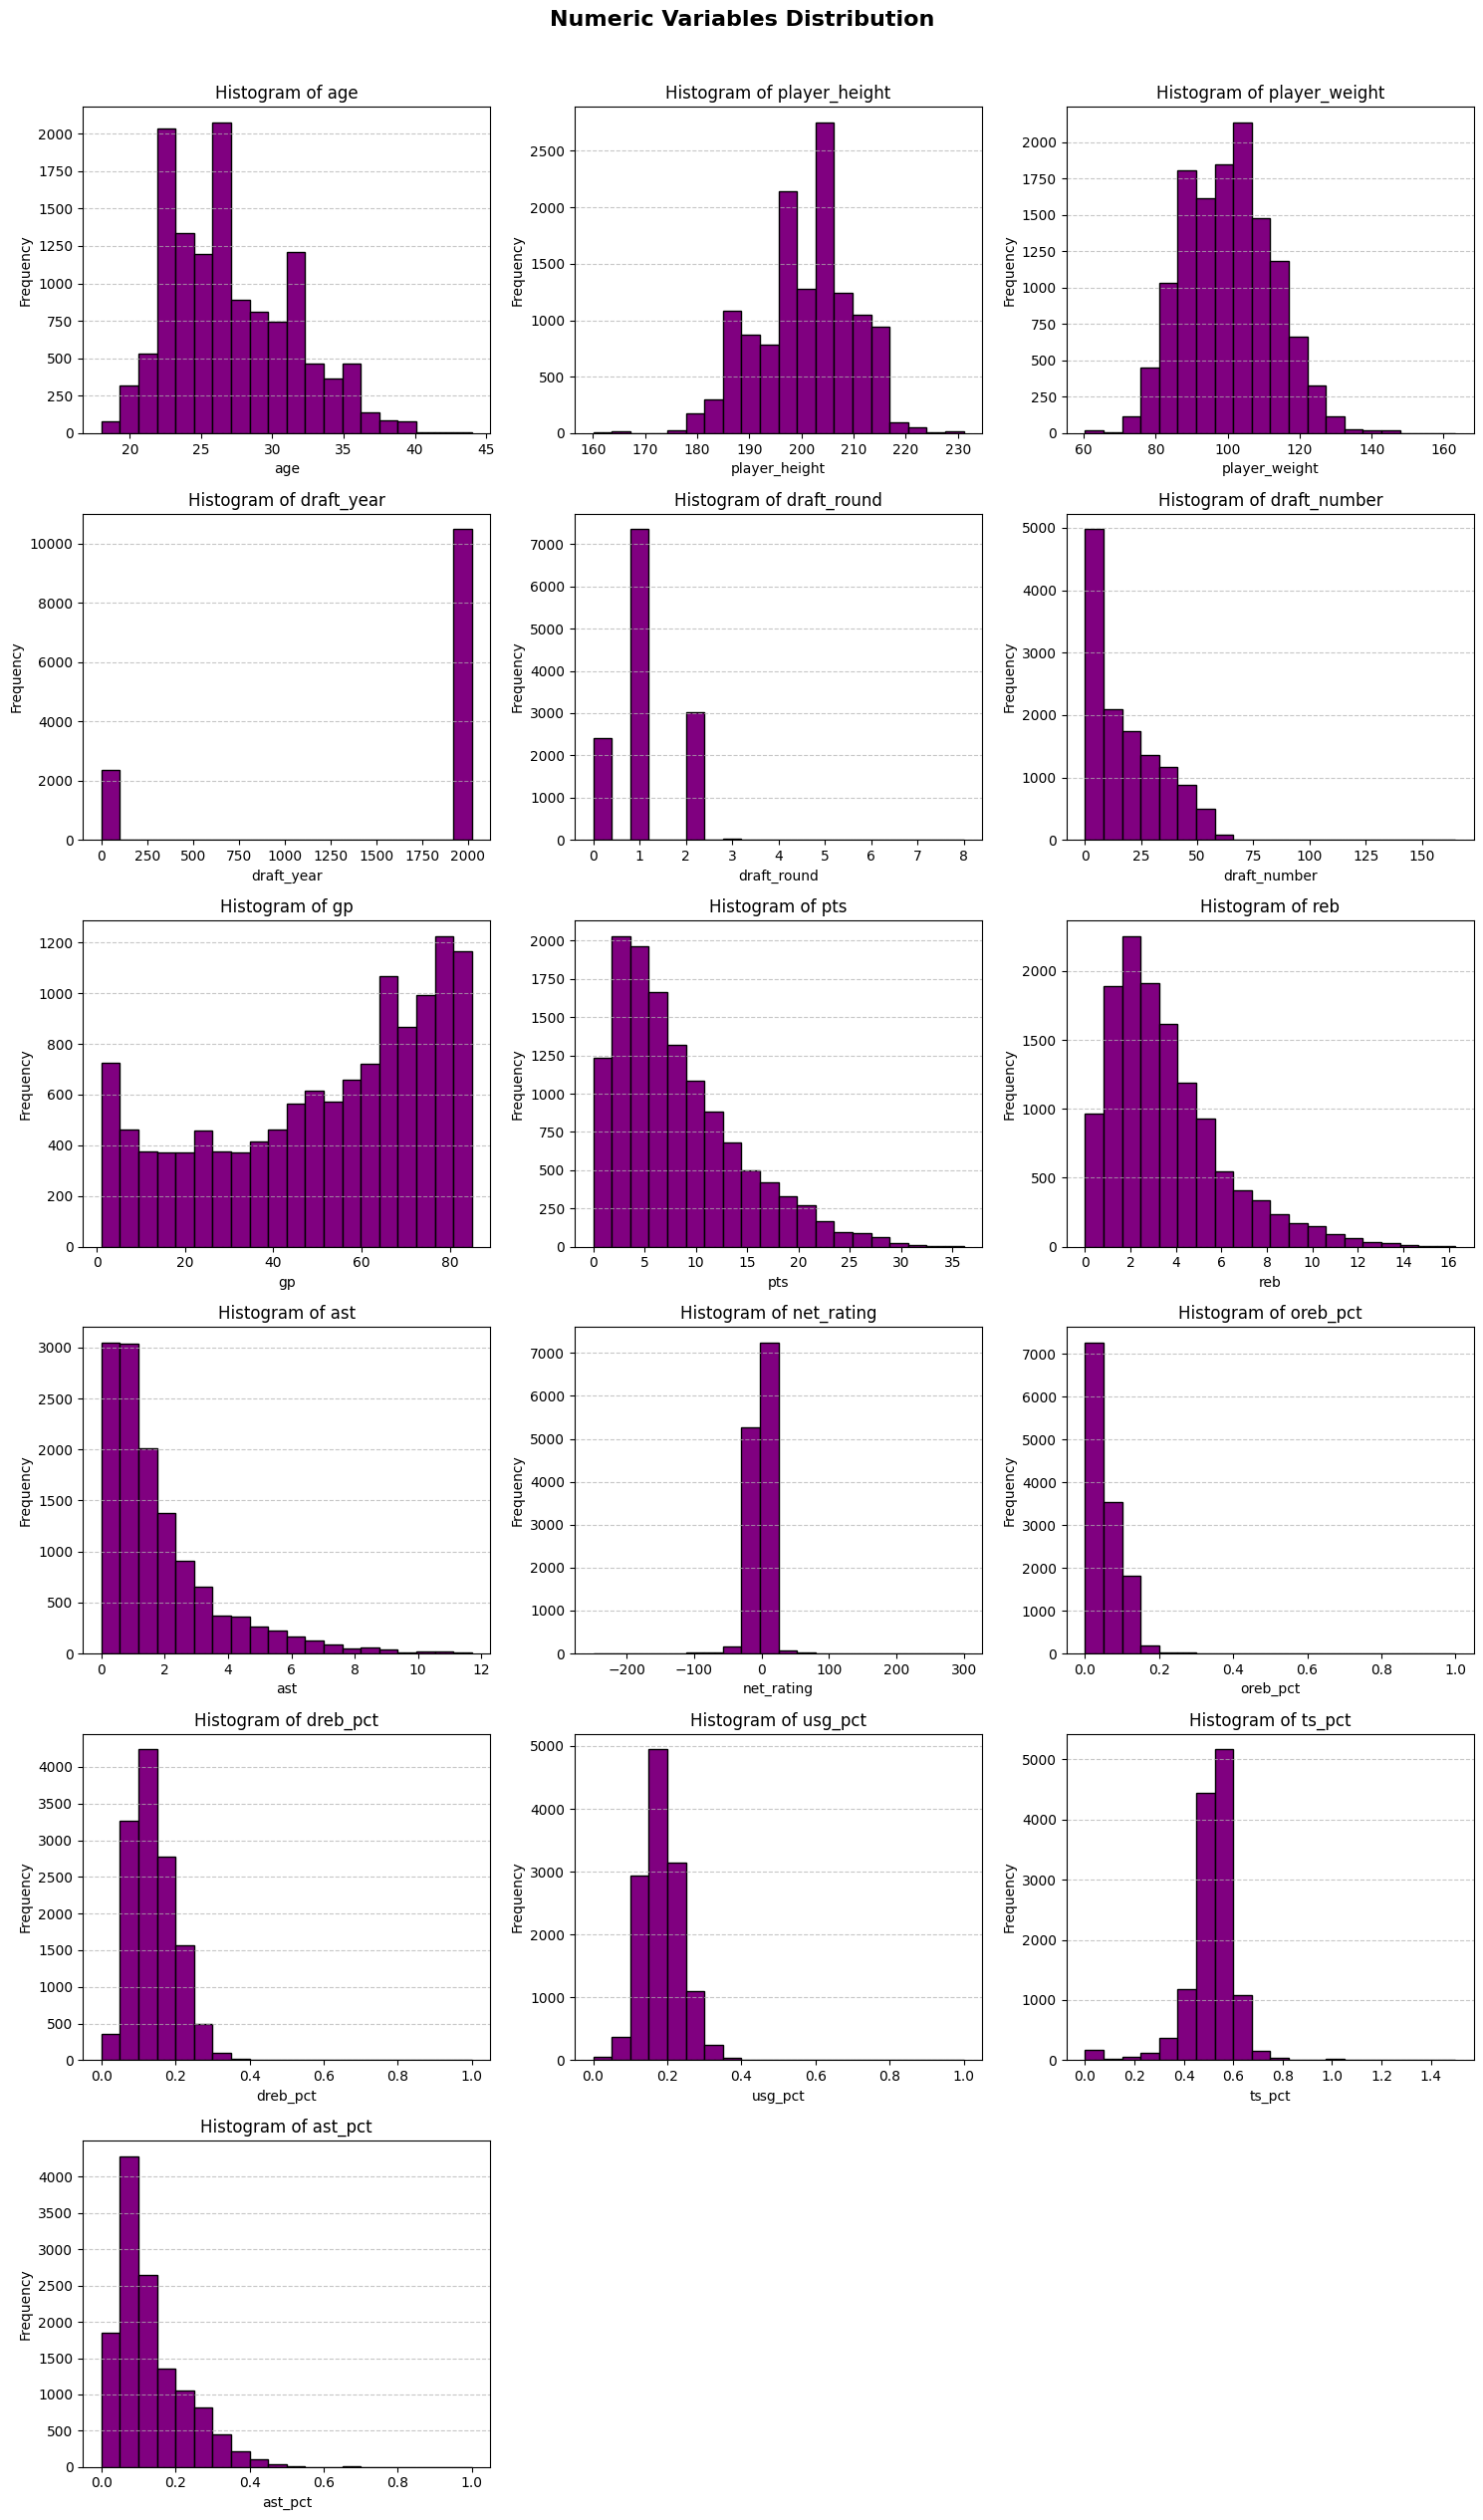

In [73]:
# Select numeric columns, excluding 'season' if it exists
numeric_columns = data.select_dtypes(include='number').drop('season', axis=1, errors='ignore')

# Create subplots for histograms
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(15, 25))
fig.suptitle('Numeric Variables Distribution', y=1.01, fontsize=16, fontweight='bold')

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Plot histograms for each numeric column
for i, column in enumerate(numeric_columns.columns):
    axes[i].hist(numeric_columns[column], bins=20, edgecolor='black', color='purple')
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplots (if the number of columns is less than the available subplots)
for j in range(len(numeric_columns.columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()


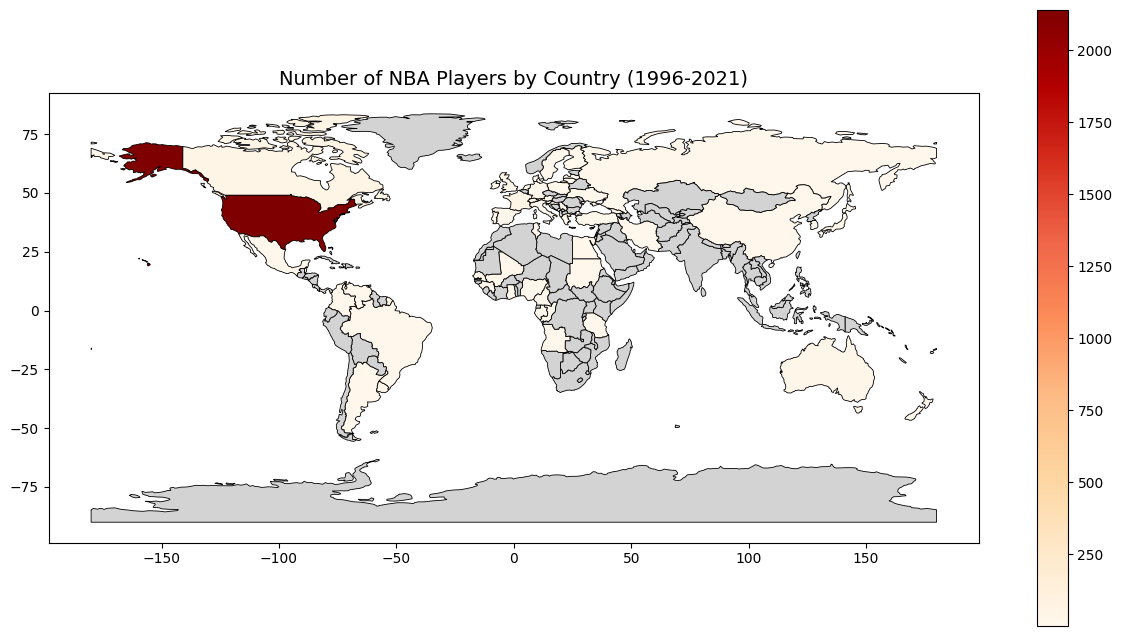

In [74]:
df_unique = data[['player_name', 'country']].drop_duplicates()

country_counts = df_unique['country'].value_counts().reset_index()
country_counts.columns = ['country', 'playerCount']
country_counts["country"] = country_counts["country"].replace({
    "USA": "United States of America"
})


world = gpd.read_file('/content/sample_data/ne_110m_admin_0_countries.shp')

world = world.merge(country_counts, how="left", left_on="NAME", right_on="country")

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
world.plot(column='playerCount', cmap='OrRd', linewidth=0.6, edgecolor='black',
           legend=True, ax=ax, missing_kwds={"color": "lightgrey"})
plt.title("Number of NBA Players by Country (1996-2021)", fontsize=14)
plt.show()

pd.set_option('display.max_rows', None)
country_counts = pd.DataFrame(df_unique.country.value_counts())
country_counts.rename(columns={"country": "players_cnt"}, inplace=True)

country_counts['relative_freq'] = ((country_counts['count'] / country_counts['count'].sum()) * 100).round(2).astype(str) + '%'


This visualization is technically correct, as it accurately represents the number of NBA players by country. However, due to the overwhelming dominance of the United States, which has a significantly higher number of players than any other country, the color scale becomes heavily skewed. As a result, differences among the remaining countries are difficult to distinguish, limiting the interpretability of the distribution. To address this issue and improve the visibility of variations across other countries, a logarithmic transformation is applied in the following visualization

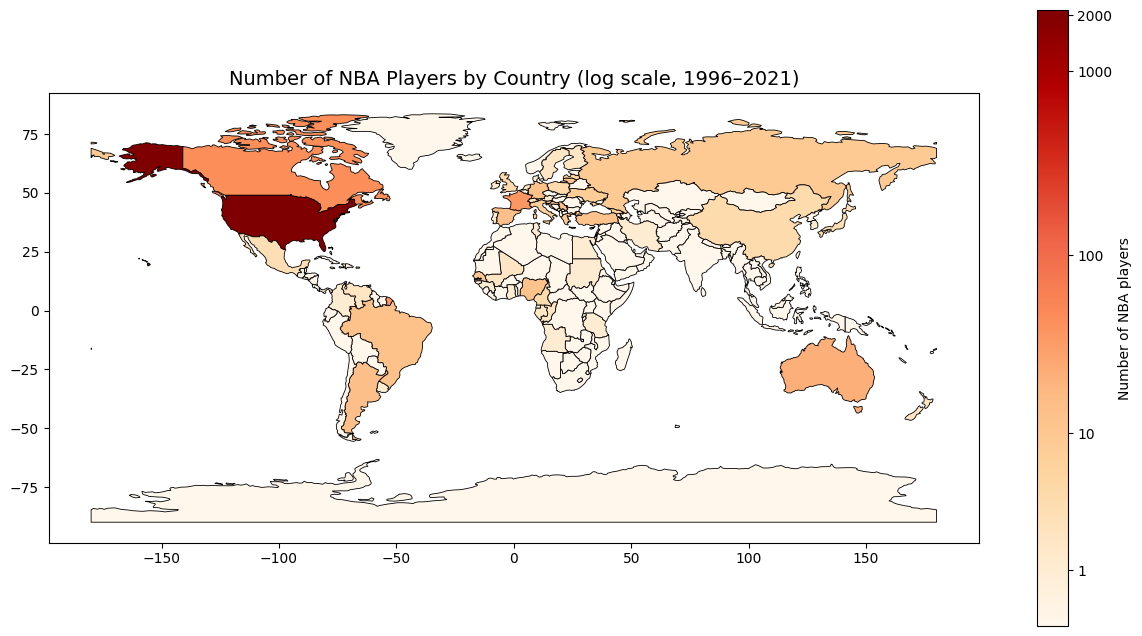

In [75]:
# log transformation
world["playerCount_log"] = np.log10(world["playerCount"].fillna(0) + 1)

fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world.plot(
    column='playerCount_log',
    cmap='OrRd',
    linewidth=0.6,
    edgecolor='black',
    legend=False,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

# custom legend (log scale --> actual values)
ticks = [1, 10, 100, 1000, 2000]
tick_locs = np.log10(np.array(ticks) + 1)

sm = plt.cm.ScalarMappable(
    cmap='OrRd',
    norm=plt.Normalize(
        vmin=world["playerCount_log"].min(),
        vmax=world["playerCount_log"].max()
    )
)

cbar = fig.colorbar(sm, ax=ax)
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([str(t) for t in ticks])
cbar.set_label("Number of NBA players")

plt.title("Number of NBA Players by Country (log scale, 1996–2021)", fontsize=14)
plt.show()


A logarithmic transformation rescales the data by compressing large values and expanding smaller ones, which reduces the influence of extreme outliers and allows differences among countries with fewer NBA players to become more visible and interpretable.

In [76]:
print("Top 10 countries with most NBA players:")
country_counts.head(n=10)

Top 10 countries with most NBA players:


,count,relative_freq
country,,
USA,2140,83.63%
Canada,45,1.76%
France,37,1.45%
Australia,22,0.86%
Serbia,15,0.59%
Croatia,15,0.59%
Argentina,14,0.55%
Spain,14,0.55%
Germany,13,0.51%


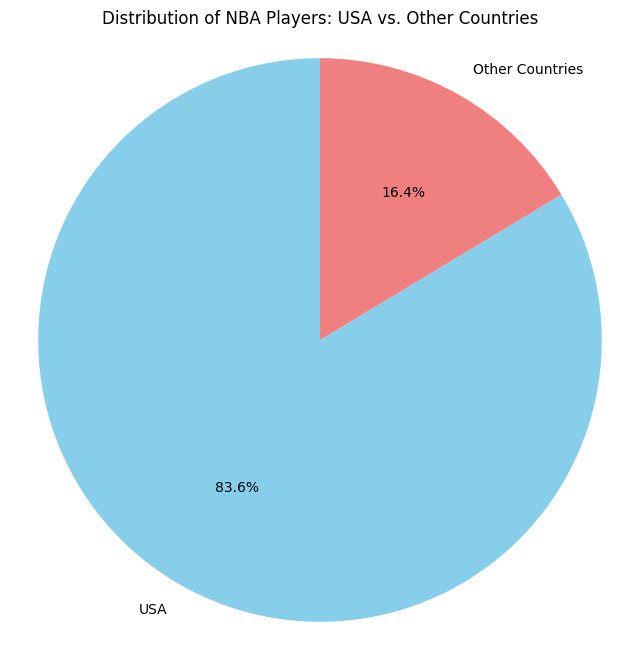

In [77]:
# Calculate the number of players from USA
country_counts_for_pie = df_unique['country'].value_counts().reset_index()
country_counts_for_pie.columns = ['country', 'playerCount']

usa_players = country_counts_for_pie[country_counts_for_pie['country'] == 'USA']['playerCount'].sum()

# Calculate the number of players from other countries
other_countries_players = country_counts_for_pie[country_counts_for_pie['country'] != 'USA']['playerCount'].sum()

# Create a DataFrame for the pie chart
pie_data = pd.DataFrame({
    'Category': ['USA', 'Other Countries'],
    'PlayerCount': [usa_players, other_countries_players]
})

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(pie_data['PlayerCount'], labels=pie_data['Category'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of NBA Players: USA vs. Other Countries')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

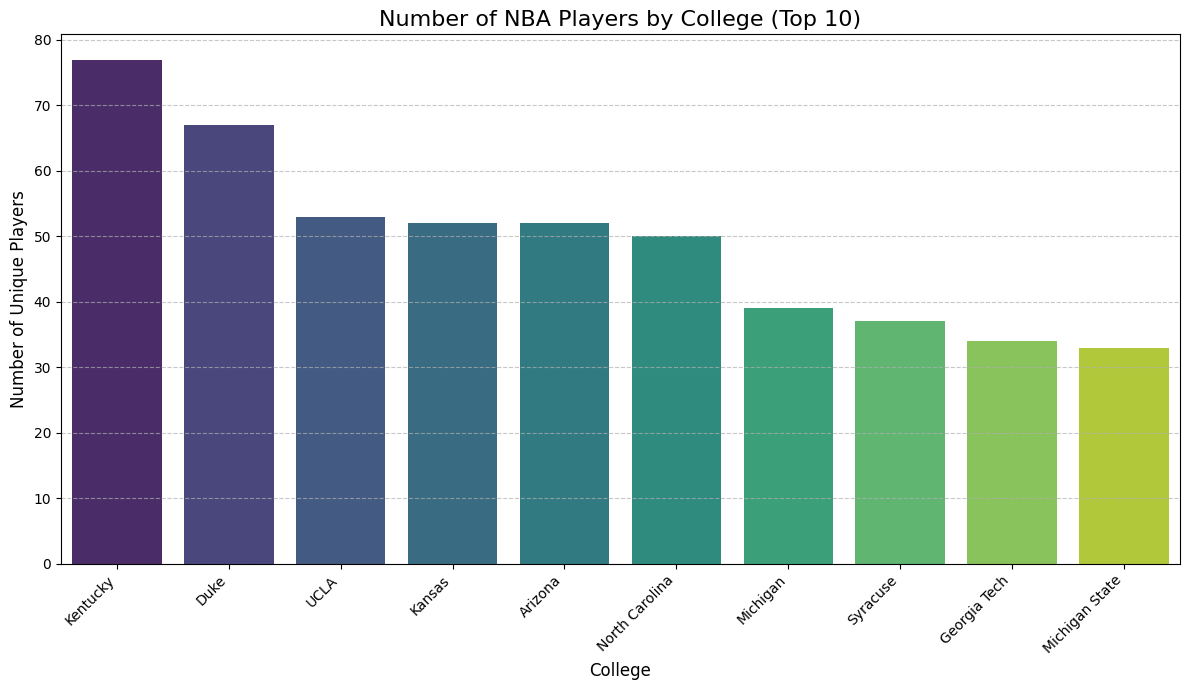

In [78]:
# Filter out players with 'No College'
players_with_college = data[data['college'] != 'No College']

# Count unique players per college
college_player_counts = players_with_college.groupby('college')['player_name'].nunique().reset_index()
college_player_counts.columns = ['college', 'player_count']

N = 10
top_n_colleges = college_player_counts.sort_values(by='player_count', ascending=False).head(N)

plt.figure(figsize=(12, 7))
sns.barplot(x='college', y='player_count', data=top_n_colleges, hue='college', palette='viridis', legend=False)
plt.title(f'Number of NBA Players by College (Top {N})', fontsize=16)
plt.xlabel('College', fontsize=12)
plt.ylabel('Number of Unique Players', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Players' longevity

In [79]:
player_seasons = data.groupby('player_name')['season'].nunique()
average_seasons = player_seasons.mean()
print(f"Average number of seasons played: {average_seasons:.2f}")

Average number of seasons played: 5.03


In [80]:
player_stats = data.groupby('player_name').agg(
    total_seasons=pd.NamedAgg(column='season', aggfunc='nunique'),
    first_season=pd.NamedAgg(column='season', aggfunc='min'),
    last_season=pd.NamedAgg(column='season', aggfunc='max')
).reset_index()

top_10_longevity_players = player_stats.sort_values(by='total_seasons', ascending=False).head(10)

display_df = top_10_longevity_players.copy()

display_df['last_season'] = display_df['last_season'].astype(str)
display_df.loc[display_df['last_season'] == '2022', 'last_season'] = 'Present'

display_df.rename(columns={'first_season': 'from', 'last_season': 'to'}, inplace=True)

print('Top 10 players by number of seasons played:')
display(display_df[['player_name', 'total_seasons', 'from', 'to']])

Top 10 players by number of seasons played:


,player_name,total_seasons,from,to
2451,Vince Carter,22,1998,2019
677,Dirk Nowitzki,21,1998,2018
2436,Udonis Haslem,20,2003,Present
1470,Kobe Bryant,20,1996,2015
1532,LeBron James,20,2003,Present
1436,Kevin Garnett,20,1996,2015
1058,Jamal Crawford,20,2000,2019
2314,Tim Duncan,19,1997,2015
95,Andre Iguodala,19,2004,Present
1931,Paul Pierce,19,1998,2016


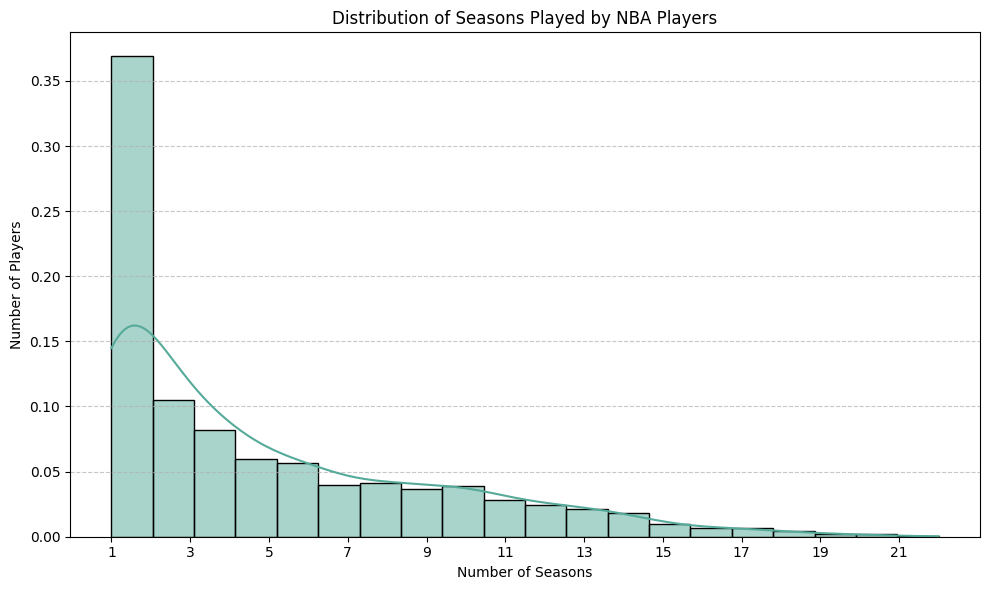

In [81]:
plt.figure(figsize=(10, 6))
sns.histplot(player_seasons, bins=20, kde=True, stat='density',
             color='#55AA99', edgecolor='black')
plt.title('Distribution of Seasons Played by NBA Players')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of Players')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(1, int(player_seasons.max()) + 1, 2))
plt.tight_layout()
plt.show()

It would be interesting to examine whether the data differs for players who, for example, were selected in the first round of the draft.

In [82]:
round1_players = data[data['draft_round'] == 1]
round1_player_seasons = round1_players.groupby('player_name')['season'].nunique()

In [83]:
round1_average_seasons = round1_player_seasons.mean()
print(f"Average number of seasons played: {round1_average_seasons:.2f}")

Average number of seasons played: 7.16


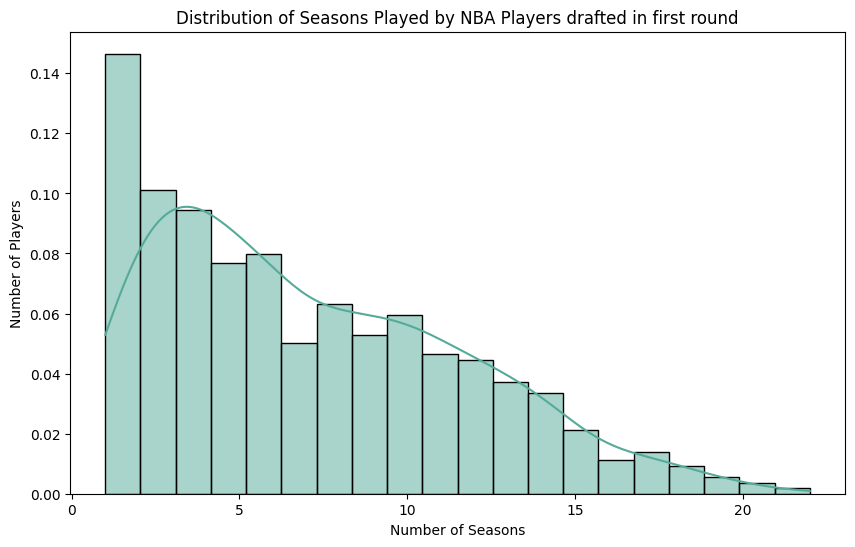

In [84]:
plt.figure(figsize=(10, 6))
sns.histplot(round1_player_seasons, bins=20, kde=True, stat='density',
             color='#55AA99', edgecolor='black')
plt.title('Distribution of Seasons Played by NBA Players drafted in first round')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of Players')
plt.show()

We can observe that players selected in the first round of the draft, on average, play significantly longer than the average player, which is expected given that they are considered the top talents of each season.

##The impact of physical attributes on the game.

###10 shortest players and their best scoring season

In [85]:
idx = data.groupby('player_name')['pts'].idxmax()
unique_players_max_pts = data.loc[idx]

shortest_unique_players = unique_players_max_pts.sort_values(by='player_height', ascending=True).head(10)

display(shortest_unique_players[['player_name', 'player_height', 'pts', 'ast']])

,player_name,player_height,pts,ast
391,Muggsy Bogues,160.02,8.0,7.2
4781,Earl Boykins,165.10,14.6,4.4
627,Spud Webb,167.64,3.0,1.3
10820,Chris Clemons,175.26,4.9,0.8
9146,Kay Felder,175.26,4.0,1.4
9537,Isaiah Thomas,175.26,28.9,5.9
12786,Jacob Gilyard,175.26,3.0,7.0
5671,Nate Robinson,175.26,17.2,4.1
3660,Yuta Tabuse,175.26,1.8,0.8
1151,Tyson Wheeler,177.80,4.0,2.0


###10 shortest players with 25+ points average


In [86]:
high_scoring_players = unique_players_max_pts[unique_players_max_pts['pts'] > 25]
sorted_high_scoring_players = high_scoring_players.sort_values(by='player_height', ascending=True)
display(sorted_high_scoring_players[['player_name', 'player_height', 'pts', 'ast']].head(10))

,player_name,player_height,pts,ast
9537,Isaiah Thomas,175.26,28.9,5.9
4302,Allen Iverson,182.88,33.0,7.4
10530,Kemba Walker,185.42,25.6,5.9
12487,Donovan Mitchell,185.42,28.3,4.4
11042,Trae Young,185.42,29.6,9.3
12564,Damian Lillard,187.96,32.2,7.3
10739,Kyrie Irving,187.96,27.4,6.4
11871,Ja Morant,190.50,27.4,6.7
6113,Monta Ellis,190.50,25.5,5.3
9309,Russell Westbrook,190.50,31.6,10.4


### Top 10 heighest players ever

In [87]:
data.sort_values(by='player_height', ascending=False).head(10)

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season,player_height_category
6,Gheorghe Muresan,WAS,26.0,231.14,137.438376,No College,USA,1993,2,30,...,6.6,0.4,6.9,0.098,0.217,0.185,0.618,0.024,1996,230-236
953,Gheorghe Muresan,NJN,28.0,231.14,137.438376,No College,USA,1993,2,30,...,0.0,0.0,-200.0,0.000,0.000,1.000,0.000,0.000,1998,230-236
1659,Gheorghe Muresan,NJN,29.0,231.14,137.438376,No College,USA,1993,2,30,...,2.3,0.3,4.8,0.103,0.163,0.202,0.492,0.056,1999,230-236
4657,Yao Ming,HOU,26.0,228.60,140.613520,No College,China,2002,1,1,...,9.4,2.0,9.3,0.076,0.238,0.331,0.601,0.115,2006,223-229
3659,Yao Ming,HOU,24.0,228.60,140.613520,No College,China,2002,1,1,...,8.4,0.8,2.0,0.102,0.215,0.264,0.614,0.048,2004,223-229
3305,Shawn Bradley,DAL,32.0,228.60,124.737800,Brigham Young,USA,1993,1,2,...,2.6,0.3,5.1,0.100,0.148,0.134,0.523,0.038,2003,223-229
633,Shawn Bradley,DAL,26.0,228.60,112.490816,Brigham Young,USA,1993,1,2,...,8.1,0.9,-2.8,0.098,0.210,0.223,0.463,0.058,1997,223-229
4950,Yao Ming,HOU,27.0,228.60,140.613520,No College,China,2002,1,1,...,10.8,2.3,4.1,0.098,0.227,0.272,0.587,0.116,2007,223-229
1108,Shawn Bradley,DAL,27.0,228.60,119.294696,Brigham Young,USA,1993,1,2,...,8.0,0.8,5.4,0.114,0.226,0.164,0.527,0.051,1998,223-229
1490,Shawn Bradley,DAL,28.0,228.60,119.294696,Brigham Young,USA,1993,1,2,...,6.5,0.8,2.6,0.093,0.179,0.165,0.521,0.049,1999,223-229


##Players' performance by height category

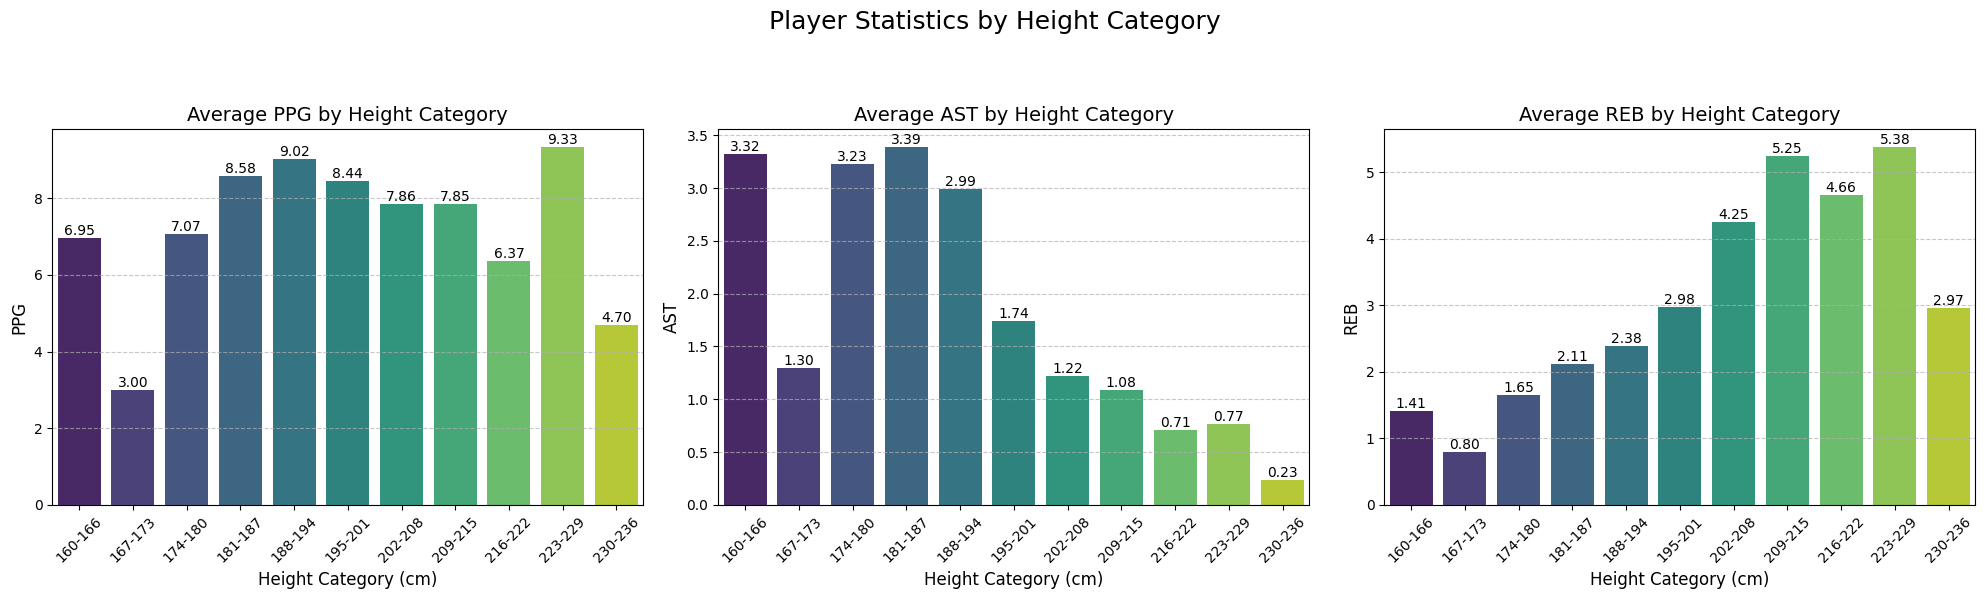

In [88]:
metrics = {'pts': 'Average PPG', 'ast': 'Average AST', 'reb': 'Average REB'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)  # Create 1 row, 3 columns of subplots
fig.suptitle('Player Statistics by Height Category', fontsize=18, y=1.02)

axes = axes.flatten()

for i, (metric_col, title_prefix) in enumerate(metrics.items()):
    # Calculate average for the current metric per player_height_category
    avg_metric_by_height = data.groupby('player_height_category')[metric_col].mean().reset_index()

    # Sort the categories by height for better visualization
    avg_metric_by_height['sort_key'] = avg_metric_by_height['player_height_category'].apply(lambda x: int(x.split('-')[0]))
    avg_metric_by_height = avg_metric_by_height.sort_values(by='sort_key').drop('sort_key', axis=1)

    # Create the bar plot on the current subplot axis
    sns.barplot(
        x='player_height_category',
        y=metric_col,
        data=avg_metric_by_height,
        palette='viridis',
        ax=axes[i]
    )
    axes[i].set_title(f'{title_prefix} by Height Category', fontsize=14)
    axes[i].set_xlabel('Height Category (cm)', fontsize=12)
    axes[i].set_ylabel(title_prefix.replace('Average ', ''), fontsize=12)  # Remove 'Average ' for y-axis label
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    # Add exact values on top of each bar
    for index, row in avg_metric_by_height.iterrows():
        axes[i].text(index, row[metric_col], f"{row[metric_col]:.2f}", color='black', ha="center", va='bottom')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make space for the suptitle
plt.show()


Correlation between height and rebounds: 0.42


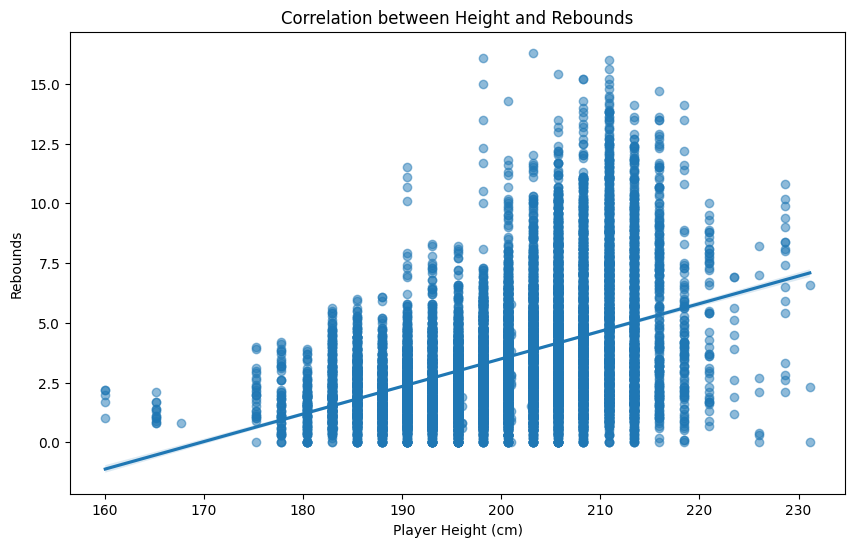

In [89]:
correlation = data['player_height'].corr(data['reb'])
print(f"Correlation between height and rebounds: {correlation:.2f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='player_height', y='reb', data=data, scatter_kws={'alpha':0.5})
plt.title('Correlation between Height and Rebounds')
plt.xlabel('Player Height (cm)')
plt.ylabel('Rebounds')
plt.show()

We can observe a clear positive correlation between a player's height and the number of rebounds. However, the tallest players don't necessarily have the highest rebound totals. This is true because extremely tall players tend to play fewer minutes, as their height makes movement more difficult, which is reflected in their lower rebound numbers

# How age influences players' performance

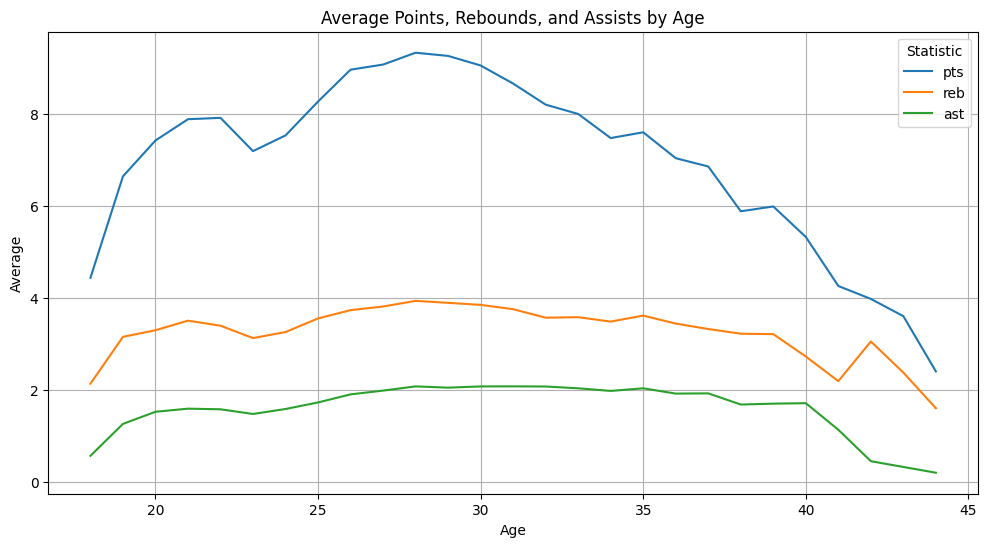

In [90]:
age_stats = data.groupby('age')[['pts', 'reb', 'ast']].mean().reset_index()

age_stats_melted = pd.melt(age_stats, id_vars=['age'], value_vars=['pts', 'reb', 'ast'],
                           var_name='Stat', value_name='Average')

plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='Average', hue='Stat', data=age_stats_melted)
plt.title('Average Points, Rebounds, and Assists by Age')
plt.xlabel('Age')
plt.ylabel('Average')
plt.legend(title='Statistic')
plt.grid(True)
plt.show()

The graph shows that points and rebounds peak in the mid-20s before declining with age, reflecting reduced physicality and stamina. Assists, on the other hand, increase early on, peaking in the late 20s, and then gradually decline as older players take on more of a playmaking role, but their overall effectiveness diminishes.

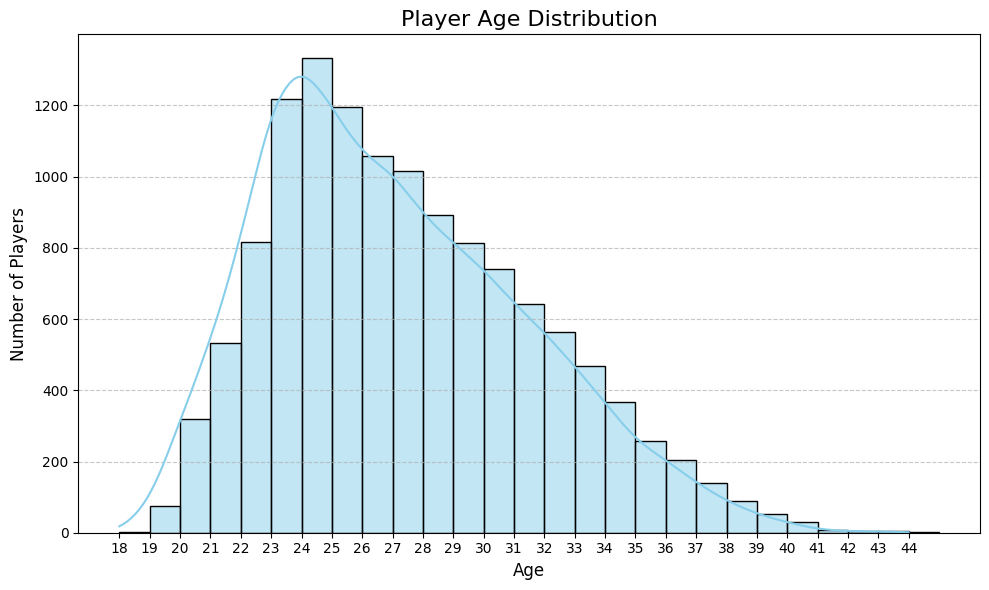

In [91]:
plt.figure(figsize=(10, 6))

age_min = int(data["age"].min())
age_max = int(data["age"].max())
bins = range(age_min, age_max + 2)

sns.histplot(
    data["age"],
    bins=bins,
    kde=True,
    color="skyblue",
    edgecolor="black"
)

plt.title("Player Age Distribution", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Players", fontsize=12)

plt.xticks(range(age_min, age_max + 1, 1))  # show each year
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


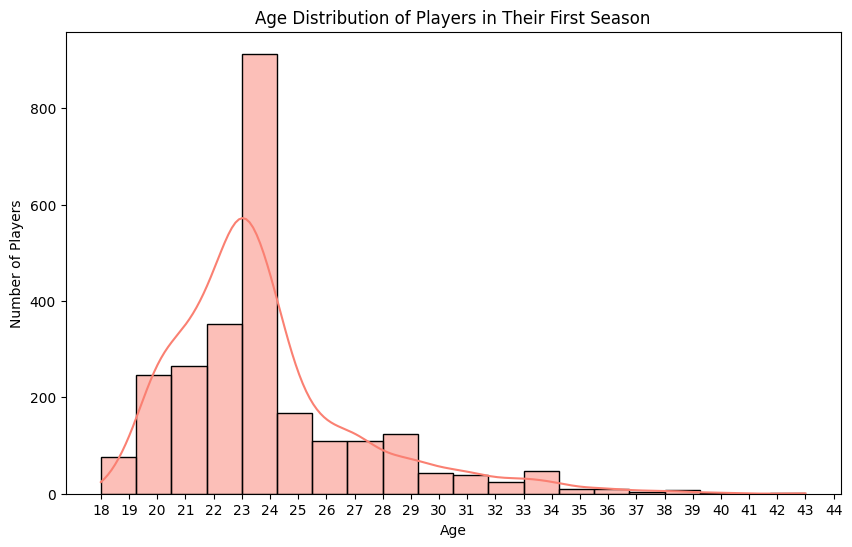

In [92]:
first_season_data = data.loc[data.groupby('player_name')['season'].idxmin()]

plt.figure(figsize=(10, 6))
sns.histplot(first_season_data['age'], bins=20, kde=True, color='salmon')
plt.xticks(range(18,45))
plt.title('Age Distribution of Players in Their First Season')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.show()

#What does the draft position tell us about a player?



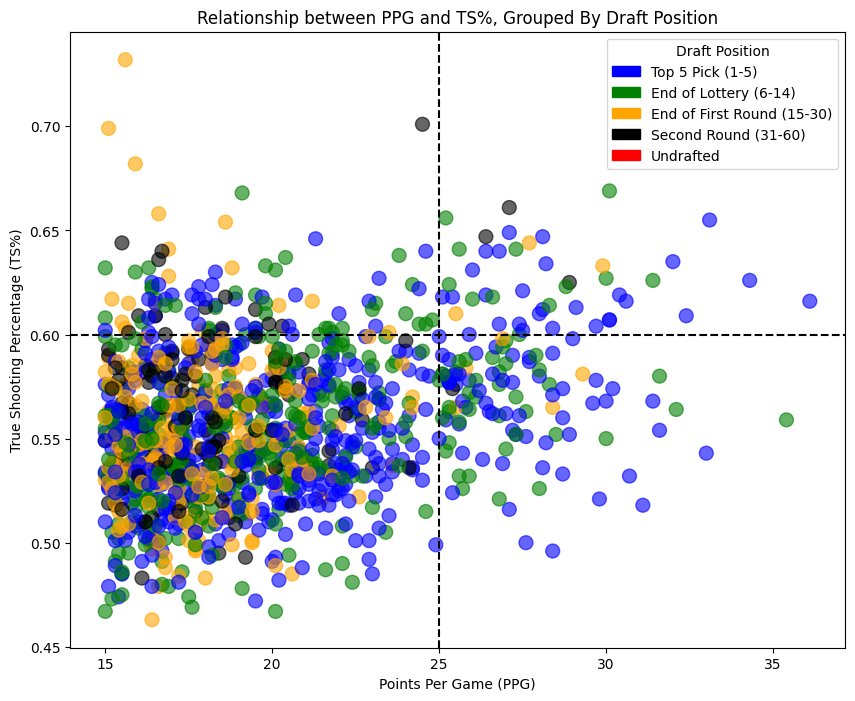

In [93]:
qualified_players = data[(data['gp'] >= 65) & (data['pts'] >= 15.0)].copy()

# Convert strings to integers in "Draft Position", coercing errors and Undrafted values to NaN
qualified_players['draft_number'] = pd.to_numeric(qualified_players['draft_number'], errors='coerce')

# Replace NaN values with 100 to use numerical sorting function in scatter plot
qualified_players['draft_number'] = qualified_players['draft_number'].fillna(100).astype(int)

# Define the x and y columns
x = qualified_players['pts']
y = qualified_players['ts_pct']

# Define a dictionary that maps colors to specific text for the legend
color_to_text_map = {
    'blue': 'Top 5 Pick (1-5)',
    'green': 'End of Lottery (6-14)',
    'orange': 'End of First Round (15-30)',
    'black': 'Second Round (31-60)',
    'red': 'Undrafted'
}
# Define the ranges for color coordination
def get_color(value):
    if value <= 5:
        return 'blue'
    elif 6 <= value < 15:
        return 'green'
    elif 15 <= value < 31:
        return 'orange'
    elif 30 <= value < 61:
        return 'black'
    else:
        return 'red'

# Apply color based on the range_column
qualified_players['color'] = qualified_players['draft_number'].apply(get_color)

# Plotting the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(x, y, c=qualified_players['color'], s=100, alpha=0.6)

# Adding quadrant lines at specific points
plt.axhline(y=0.60, color='black', linestyle='--')  # Horizontal line at 25 PPG
plt.axvline(x=25, color='black', linestyle='--')  # Vertical line at 60% TS

# Adding labels and title
plt.xlabel('Points Per Game (PPG)')
plt.ylabel('True Shooting Percentage (TS%)')
plt.title('Relationship between PPG and TS%, Grouped By Draft Position')

# Creating a custom legend based on color and text mapping

patches = [mpatches.Patch(color=color, label=text) for color, text in color_to_text_map.items()]
plt.legend(handles=patches, title="Draft Position")

# Display the plot
plt.show()

While draft position plays a role in clustering, most players, regardless of draft tier, tend to have **similar TS%** around the 0.60 mark. Notably, players with higher PPG often maintain efficiency, with a few exceptions at both ends of the spectrum. The draft position indicates a tendency for **higher picks** (Top 5, Lottery) to have **slightly better shooting efficiency**, but the overall trend shows overlap in performance.

Total Counts for Each Draft Position Group in Each Quadrant:
                            Total Players  Quadrant 1 (Top-Right)  \
draft_group                                                         
Top 5 Pick (1-5)                     4145                      45   
End of First Round (15-30)           3325                       7   
Second Round (31-60)                 2877                       3   
Rest of Lottery (6-14)               2470                      19   
Undrafted                              27                       0   

                            Quadrant 2 (Top-Left)  Quadrant 3 (Bottom-Left)  \
draft_group                                                                   
Top 5 Pick (1-5)                              424                      3590   
End of First Round (15-30)                    264                      3048   
Second Round (31-60)                          336                      2535   
Rest of Lottery (6-14)                        221           

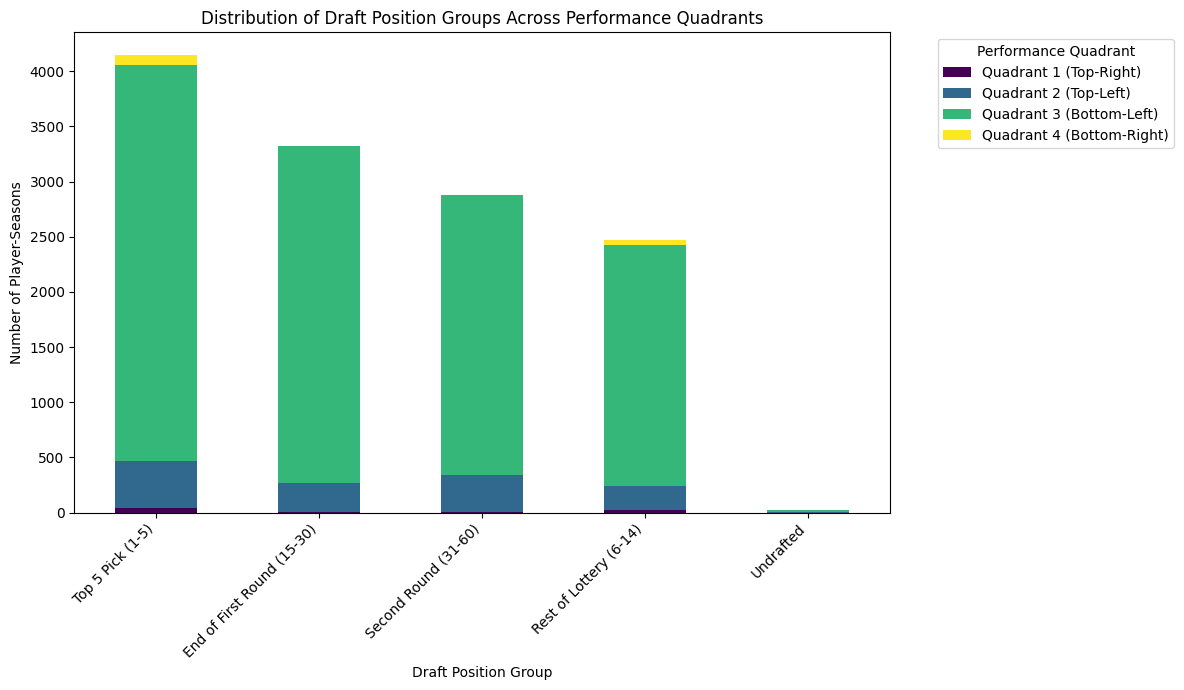

In [94]:
# Function to determine the quadrant based on PPG and TS%
def determine_quadrant(row):
    if row['pts'] >= 25 and row['ts_pct'] >= 0.60:
        return 'Quadrant 1 (Top-Right)'
    elif row['pts'] < 25 and row['ts_pct'] >= 0.60:
        return 'Quadrant 2 (Top-Left)'
    elif row['pts'] < 25 and row['ts_pct'] < 0.60:
        return 'Quadrant 3 (Bottom-Left)'
    else:
        return 'Quadrant 4 (Bottom-Right)'

# Apply quadrant classification
data['quadrant'] = data.apply(determine_quadrant, axis=1)

# Define draft position groups
def get_draft_group(draft_number):
    if draft_number <= 5:
        return 'Top 5 Pick (1-5)'
    elif 6 <= draft_number < 15:
        return 'Rest of Lottery (6-14)'
    elif 15 <= draft_number < 31:
        return 'End of First Round (15-30)'
    elif 31 <= draft_number < 61:
        return 'Second Round (31-60)'
    else:
        return 'Undrafted'

# Apply draft position group classification
data['draft_group'] = data['draft_number'].apply(get_draft_group)

# Calculate the count of each draft position group in each quadrant
def calculate_counts(data):
    # Calculate the count of each draft position group in each quadrant
    quadrant_counts = data.groupby(['draft_group', 'quadrant']).size().unstack(fill_value=0)

    # Calculate the total count of players in each draft position group
    total_counts = data['draft_group'].value_counts()

    # Combine total counts with quadrant counts
    results = pd.concat([total_counts.rename('Total Players'), quadrant_counts], axis=1)

    return results

# Calculate and print counts
results = calculate_counts(data)

# Print the results in a table format
print("Total Counts for Each Draft Position Group in Each Quadrant:")
print(results)

# Prepare data for plotting
plot_data = results.drop(columns=['Total Players'])
plot_data.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis')
plt.title('Distribution of Draft Position Groups Across Performance Quadrants')
plt.xlabel('Draft Position Group')
plt.ylabel('Number of Player-Seasons')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Performance Quadrant', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The graph reveals that Top 5 picks are well-distributed across all quadrants, with many in the Top-Right (high PPG and TS%). On the other hand, players from the second round and undrafted players are mostly concentrated in the Bottom-Left and Bottom-Right quadrants, indicating lower efficiency and/or scoring. The End of First Round (15-30) players also show a similar trend, with a majority in the Bottom-Left.

##Are American players picked earlier in the draft than international players?

Null hypothesis (H₀): The distribution of draft numbers is the same for USA and Other players.

Alternative hypothesis (H₁): The distribution of draft numbers is different for USA and Other players.

Average draft number for USA players: 21.65
Average draft number for Other players: 23.11

Mann-Whitney U Test: Statistics=7127849.50, p-value=0.000
There is a statistically significant difference in draft positions between USA and Other players.
On average, USA players tend to be picked earlier in the draft.


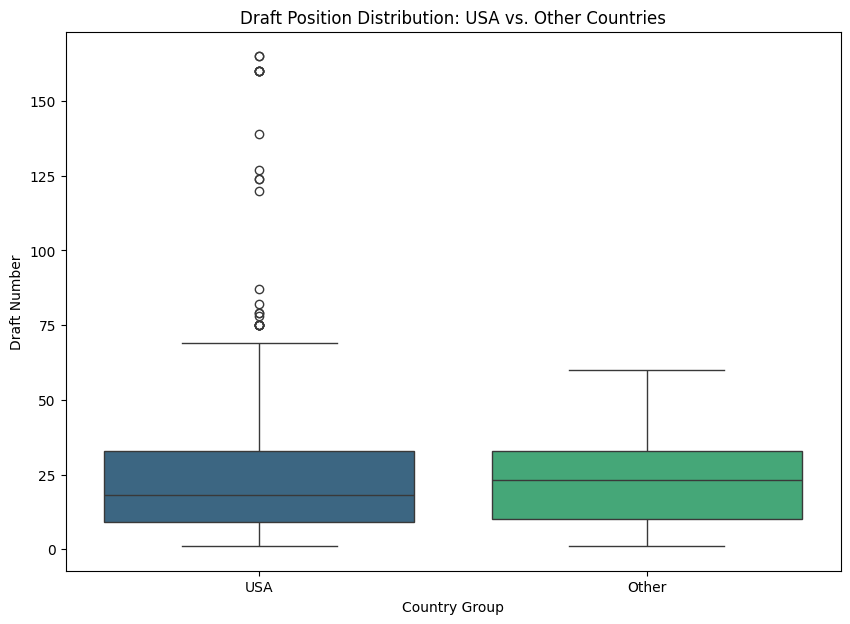

In [95]:

# 1. Create 'country_group' column
data['country_group'] = data['country'].apply(lambda x: 'USA' if x == 'USA' else 'Other')

# 2. Filter out undrafted players (draft_number = 0)
drafted_players = data[data['draft_number'] != 0].copy()

# 3. Get draft numbers for USA and Other groups
usa_draft_numbers = drafted_players[drafted_players['country_group'] == 'USA']['draft_number']
other_draft_numbers = drafted_players[drafted_players['country_group'] == 'Other']['draft_number']

print(f"Average draft number for USA players: {usa_draft_numbers.mean():.2f}")
print(f"Average draft number for Other players: {other_draft_numbers.mean():.2f}")

# Perform Mann-Whitney U test (non-parametric alternative to t-test for non-normal data)
# Null hypothesis: The distribution of draft numbers is the same for USA and Other players.
# Alternative hypothesis: The distribution of draft numbers is different for USA and Other players.
stat, p = mannwhitneyu(usa_draft_numbers, other_draft_numbers, alternative='two-sided')

print(f"\nMann-Whitney U Test: Statistics={stat:.2f}, p-value={p:.3f}")

if p < 0.05:
    print("There is a statistically significant difference in draft positions between USA and Other players.")
    if usa_draft_numbers.mean() < other_draft_numbers.mean():
        print("On average, USA players tend to be picked earlier in the draft.")
    else:
        print("On average, Other players tend to be picked earlier in the draft.")
else:
    print("There is no statistically significant difference in draft positions between USA and Other players.")

# 4. Create a boxplot for visualization
plt.figure(figsize=(10, 7))
sns.boxplot(x='country_group', y='draft_number', data=drafted_players, palette='viridis')
plt.title('Draft Position Distribution: USA vs. Other Countries')
plt.xlabel('Country Group')
plt.ylabel('Draft Number')
plt.show()

The boxplot reveals a significant difference in the draft position distribution between USA and Other countries. On average, USA players tend to be picked earlier in the draft, with an average draft number of 21.65, compared to 23.11 for players from other countries. The Mann-Whitney U Test confirms that this difference is statistically significant, indicating that players from the USA are more likely to be drafted in higher positions.

USA players are typically drafted earlier due to their exposure in well-established college programs, which provide greater scouting visibility, while international players often face later draft positions due to less exposure and competition in their leagues.

#What does the college tell us about a player?

##Is there a link between college and specific stats (PTS/AST/REB)?

Shapiro-Wilk Test for Normality (pts_pg):
  Kentucky: Statistics=0.931, p=0.000
  Duke: Statistics=0.934, p=0.002
  UCLA: Statistics=0.861, p=0.000
  Kansas: Statistics=0.845, p=0.000
  Arizona: Statistics=0.943, p=0.017
  North Carolina: Statistics=0.904, p=0.001
  Michigan: Statistics=0.922, p=0.010
  Syracuse: Statistics=0.867, p=0.000
  Michigan State: Statistics=0.915, p=0.013
  Georgia Tech: Statistics=0.912, p=0.013


Levene's Test for Homogeneity of Variances (pts_pg):
  Statistics=0.820, p=0.598


ANOVA for pts_pg:
                  sum_sq     df         F    PR(>F)
C(college)    493.861482    9.0  1.887243  0.051749
Residual    13869.260546  477.0       NaN       NaN


ANOVA not significant (p >= 0.05) for pts_pg. No post-hoc test performed.




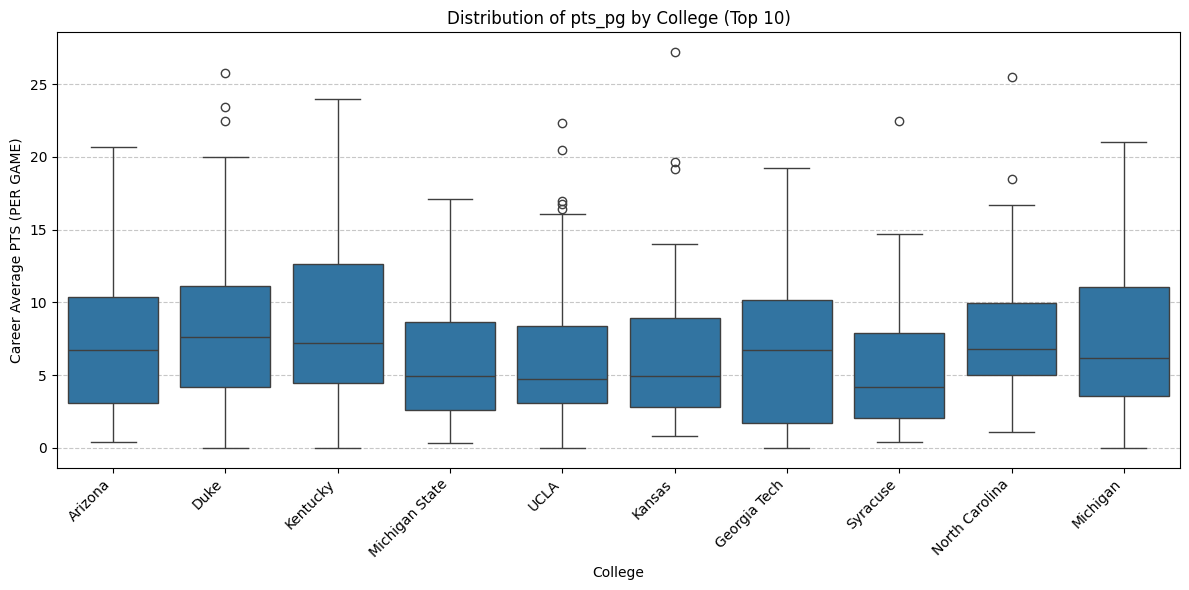

Shapiro-Wilk Test for Normality (ast_pg):
  Kentucky: Statistics=0.829, p=0.000
  Duke: Statistics=0.925, p=0.001
  UCLA: Statistics=0.773, p=0.000
  Kansas: Statistics=0.820, p=0.000
  Arizona: Statistics=0.865, p=0.000
  North Carolina: Statistics=0.807, p=0.000
  Michigan: Statistics=0.805, p=0.000
  Syracuse: Statistics=0.810, p=0.000
  Michigan State: Statistics=0.795, p=0.000
  Georgia Tech: Statistics=0.827, p=0.000


Levene's Test for Homogeneity of Variances (ast_pg):
  Statistics=1.255, p=0.259


ANOVA for ast_pg:
                 sum_sq     df         F    PR(>F)
C(college)    28.216912    9.0  1.363179  0.202159
Residual    1097.065103  477.0       NaN       NaN


ANOVA not significant (p >= 0.05) for ast_pg. No post-hoc test performed.




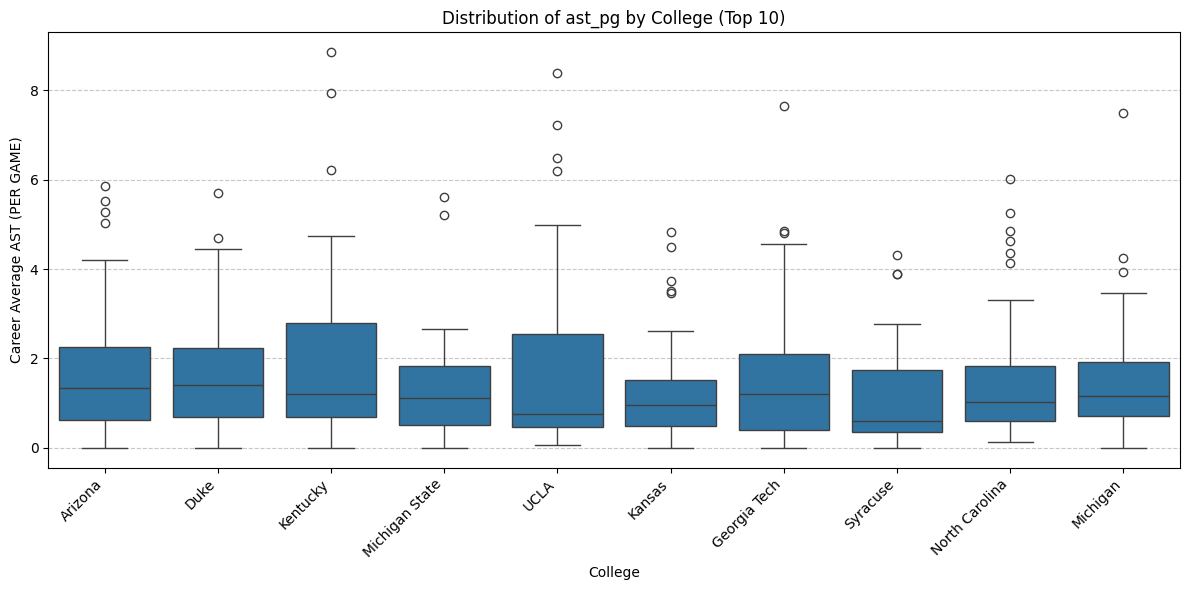

Shapiro-Wilk Test for Normality (reb_pg):
  Kentucky: Statistics=0.903, p=0.000
  Duke: Statistics=0.918, p=0.000
  UCLA: Statistics=0.840, p=0.000
  Kansas: Statistics=0.902, p=0.000
  Arizona: Statistics=0.882, p=0.000
  North Carolina: Statistics=0.971, p=0.257
  Michigan: Statistics=0.893, p=0.001
  Syracuse: Statistics=0.866, p=0.000
  Michigan State: Statistics=0.909, p=0.009
  Georgia Tech: Statistics=0.878, p=0.002


Levene's Test for Homogeneity of Variances (reb_pg):
  Statistics=0.989, p=0.448


ANOVA for reb_pg:
                 sum_sq     df         F    PR(>F)
C(college)    67.835948    9.0  1.772727  0.070998
Residual    2028.120941  477.0       NaN       NaN


ANOVA not significant (p >= 0.05) for reb_pg. No post-hoc test performed.




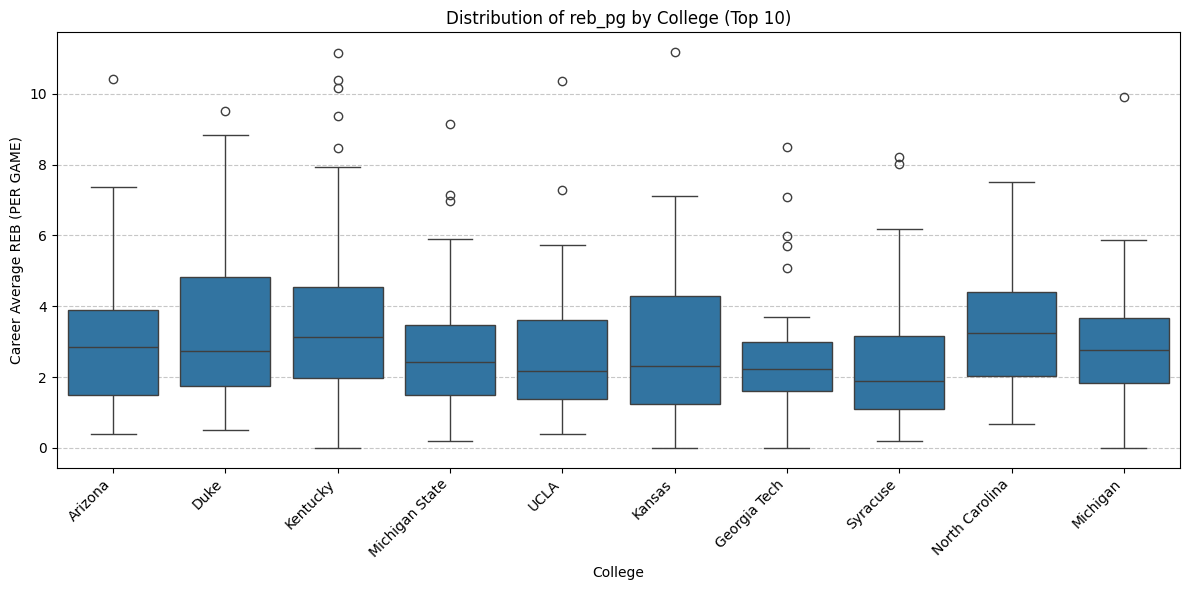

In [96]:
# First, create the comprehensive player_stats DataFrame with career averages and college info.
# This assumes 'data' DataFrame is available from previous cells.

# Aggregate season-level data to player-level career stats using .apply()
player_stats = data.groupby('player_name').apply(
    lambda group: pd.Series({
        'total_seasons': group['season'].nunique(),
        'first_season': group['season'].min(),
        'last_season': group['season'].max(),
        'total_career_pts': (group['pts'] * group['gp']).sum(),
        'total_career_ast': (group['ast'] * group['gp']).sum(),
        'total_career_reb': (group['reb'] * group['gp']).sum(),
        'career_gp': group['gp'].sum(),
        'college': group['college'].iloc[0],
        'country': group['country'].iloc[0],
        'draft_number': group['draft_number'].iloc[0],
        'draft_round': group['draft_round'].iloc[0],
        'draft_year': group['draft_year'].iloc[0],
    })
).reset_index()

# Calculate per game averages based on career totals
# Filter out players with 0 career games to avoid division by zero
player_stats = player_stats[player_stats['career_gp'] > 0].copy()
player_stats['pts_pg'] = player_stats['total_career_pts'] / player_stats['career_gp']
player_stats['ast_pg'] = player_stats['total_career_ast'] / player_stats['career_gp']
player_stats['reb_pg'] = player_stats['total_career_reb'] / player_stats['career_gp']

# Now proceed with the original analysis requested by the user:
performance_metrics = ['pts_pg', 'ast_pg', 'reb_pg']

# Identify the top 10 colleges based on the number of unique players, excluding 'No College'
top_colleges = player_stats[player_stats['college'] != 'No College']['college'].value_counts().head(10).index

# Filter the dataset to include only players from these top 10 colleges
filtered_player_stats = player_stats[player_stats['college'].isin(top_colleges)]

for metric in performance_metrics:
    data_metric = filtered_player_stats[[metric, 'college']]

    print(f"Shapiro-Wilk Test for Normality ({metric}):")
    # Test normality of the distribution within each college using the Shapiro–Wilk test.
    # Shapiro-Wilk requires at least 3 samples.
    shapiro_p_values = {}
    for college in top_colleges:
        college_data = data_metric[data_metric['college'] == college][metric]
        if len(college_data) >= 3:
            stat, p = shapiro(college_data)
            shapiro_p_values[college] = p
            print(f"  {college}: Statistics={stat:.3f}, p={p:.3f}")
        else:
            print(f"  {college}: Not enough data (less than 3 samples) for Shapiro-Wilk test.")
            shapiro_p_values[college] = float('nan') # Indicate test not run
    print("\n")

    print(f"Levene's Test for Homogeneity of Variances ({metric}):")
    # Test homogeneity of variances across colleges using Levene’s test.
    # Levene's requires at least two groups with at least 2 data points each.
    groups = [data_metric[data_metric['college'] == college][metric] for college in top_colleges if len(data_metric[data_metric['college'] == college][metric]) > 1]
    levene_p_value = float('nan')
    if len(groups) >= 2:
        stat, p_levene = levene(*groups)
        levene_p_value = p_levene
        print(f"  Statistics={stat:.3f}, p={p_levene:.3f}")
    else:
        print(f"  Not enough valid groups (at least two groups with >1 sample) for Levene's test. Groups found: {len(groups)}")
    print("\n")

    # Perform a one-way ANOVA
    model = smf.ols(f'{metric} ~ C(college)', data=filtered_player_stats).fit()
    anova_table = smsa.anova_lm(model, typ=2)

    print(f"ANOVA for {metric}:")
    print(anova_table)
    print("\n")

    # If the ANOVA is significant (p < 0.05), apply an appropriate post-hoc test
    if not anova_table.empty and anova_table['PR(>F)'][0] < 0.05:
        print(f"ANOVA significant (p < 0.05) for {metric}. Performing post-hoc test.")
        significant_differences = pd.DataFrame()

        # Use Tukey’s HSD if variances are homogeneous (Levene's p > 0.05), otherwise, use Games–Howell
        if not pd.isna(levene_p_value) and levene_p_value > 0.05:
            print(f"Variances are homogeneous (Levene's p > 0.05). Performing Tukey's HSD for {metric}:")
            # Ensure no groups have zero variance for Tukey, which can happen with small N
            try:
                post_hoc_result = pairwise_tukeyhsd(filtered_player_stats[metric], filtered_player_stats['college'], alpha=0.05)
                post_hoc_df = pd.DataFrame(data=post_hoc_result._results_table.data[1:], columns=post_hoc_result._results_table.data[0])
                significant_differences = post_hoc_df[post_hoc_df['p-adj'] < 0.05]
                print(significant_differences)
            except ValueError as e:
                print(f"Could not perform Tukey's HSD due to: {e}. This might happen if groups have zero variance.")
        else:
            print(f"Variances are not homogeneous (Levene's p <= 0.05) or test could not be performed. Performing Games-Howell post hoc test for {metric}:")
            # Games-Howell requires pingouin, which is already imported.
            try:
                post_hoc_result = pg.pairwise_gameshowell(data=filtered_player_stats, dv=metric, between='college')
                significant_differences = post_hoc_result[post_hoc_result['pval'] < 0.05]
                print(significant_differences[['group1', 'group2', 'mean1', 'mean2', 'pval', 'hedges']]) # Display relevant columns
            except ValueError as e:
                print(f"Could not perform Games-Howell due to: {e}. Check if groups have sufficient variability.")

        print("\n")
        if not significant_differences.empty:
            # Summarize the average mean differences by college
            print(f"Summary of mean {metric} for colleges with significant pairwise differences:")
            # Extract colleges involved in significant differences
            involved_colleges = pd.concat([significant_differences['group1'], significant_differences['group2']]).unique()
            college_means_significant = filtered_player_stats[filtered_player_stats['college'].isin(involved_colleges)].groupby('college')[metric].mean().sort_values(ascending=False)
            print(college_means_significant)
            print("\n")
        else:
            print(f"No significant pairwise differences found for {metric} after post-hoc test.")
    else:
        print(f"ANOVA not significant (p >= 0.05) for {metric}. No post-hoc test performed.")
    print("\n")

    # Visualize the distribution of each performance metric across the top 10 colleges using boxplots.
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='college', y=metric, data=filtered_player_stats)
    plt.title(f'Distribution of {metric} by College (Top 10)')
    plt.xlabel('College')
    plt.ylabel(f'Career Average {metric.replace("_pg", " (per game)").upper()}')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Points:
The ANOVA test shows that the difference in average points per game (pts_pg) between players from the analyzed colleges is not statistically significant (p=0.0517). This suggests that the college a player attended has no significant impact on their NBA points average, at least not within this group of colleges.

Assists:
The ANOVA test shows that the difference in average assists per game (ast_pg) between players from the analyzed colleges is not statistically significant (p=0.202). This suggests that the college a player attended has no significant impact on their NBA assist average, at least not within this group of colleges.

Rebounds:
The ANOVA test shows that the difference in average rebounds per game (reb_pg) between players from the analyzed colleges is not statistically significant (p=0.071). This suggests that the college a player attended has no significant impact on their NBA rebound average, at least not within this group of colleges.

Final conclusion: The college a player attended **does not** significantly impact their NBA performance in points, assists, or rebounds.

#Which nations have the best players?

##Is there a link between college and specific stats (PTS/AST/REB)?

Shapiro-Wilk Test for Normality (pts_pg):
  USA: Statistics=0.894, p=0.000
  Canada: Statistics=0.915, p=0.003
  France: Statistics=0.933, p=0.027
  Australia: Statistics=0.826, p=0.001
  Serbia: Statistics=0.838, p=0.012
  Croatia: Statistics=0.931, p=0.280
  Argentina: Statistics=0.903, p=0.124
  Spain: Statistics=0.943, p=0.464
  Germany: Statistics=0.924, p=0.286
  Brazil: Statistics=0.903, p=0.149


Levene's Test for Homogeneity of Variances (pts_pg):
  Statistics=0.821, p=0.596


Performing Kruskal-Wallis test for pts_pg:
H-statistic: 11.418, p-value: 0.248


Eta-squared for pts_pg: 0.005


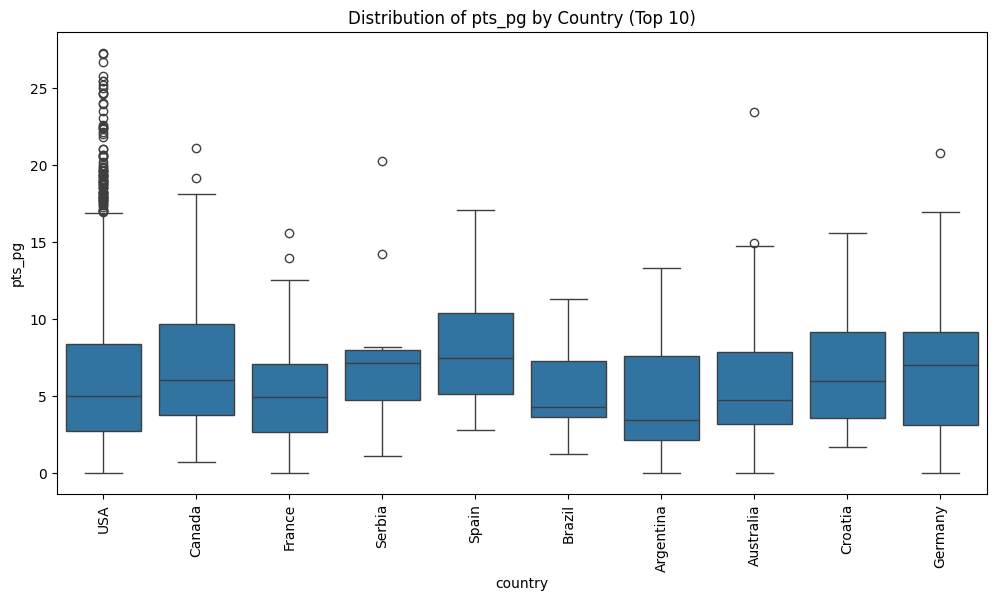

Shapiro-Wilk Test for Normality (ast_pg):
  USA: Statistics=0.794, p=0.000
  Canada: Statistics=0.789, p=0.000
  France: Statistics=0.763, p=0.000
  Australia: Statistics=0.814, p=0.001
  Serbia: Statistics=0.824, p=0.008
  Croatia: Statistics=0.857, p=0.022
  Argentina: Statistics=0.930, p=0.310
  Spain: Statistics=0.871, p=0.043
  Germany: Statistics=0.862, p=0.041
  Brazil: Statistics=0.913, p=0.203


Levene's Test for Homogeneity of Variances (ast_pg):
  Statistics=1.597, p=0.111


Performing Kruskal-Wallis test for ast_pg:
H-statistic: 11.930, p-value: 0.217


Eta-squared for ast_pg: 0.005


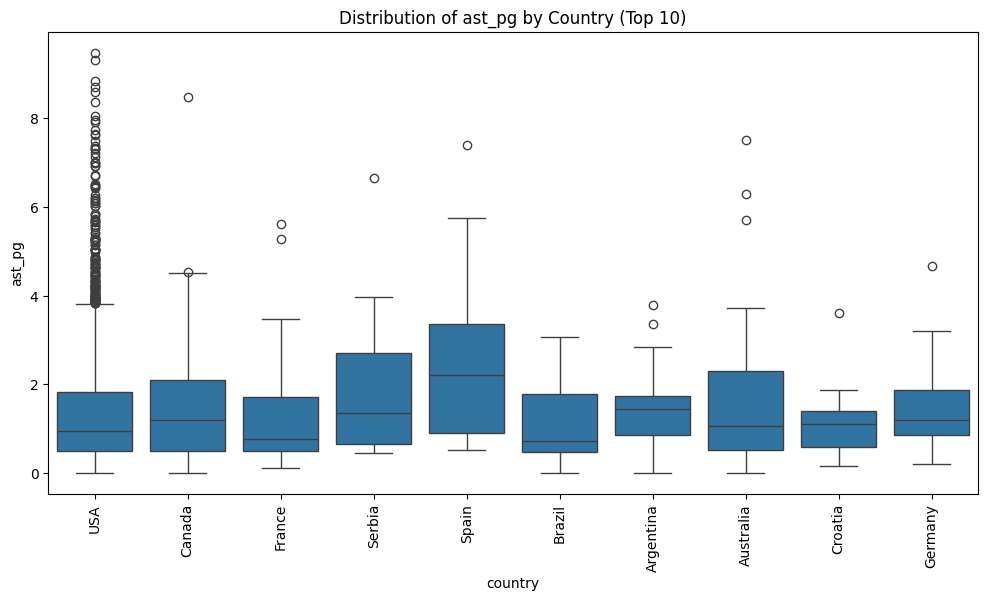

Shapiro-Wilk Test for Normality (reb_pg):
  USA: Statistics=0.898, p=0.000
  Canada: Statistics=0.963, p=0.162
  France: Statistics=0.766, p=0.000
  Australia: Statistics=0.854, p=0.004
  Serbia: Statistics=0.833, p=0.010
  Croatia: Statistics=0.949, p=0.506
  Argentina: Statistics=0.900, p=0.113
  Spain: Statistics=0.860, p=0.030
  Germany: Statistics=0.956, p=0.687
  Brazil: Statistics=0.933, p=0.370


Levene's Test for Homogeneity of Variances (reb_pg):
  Statistics=0.224, p=0.991


Performing Kruskal-Wallis test for reb_pg:
H-statistic: 12.543, p-value: 0.184


Eta-squared for reb_pg: 0.005


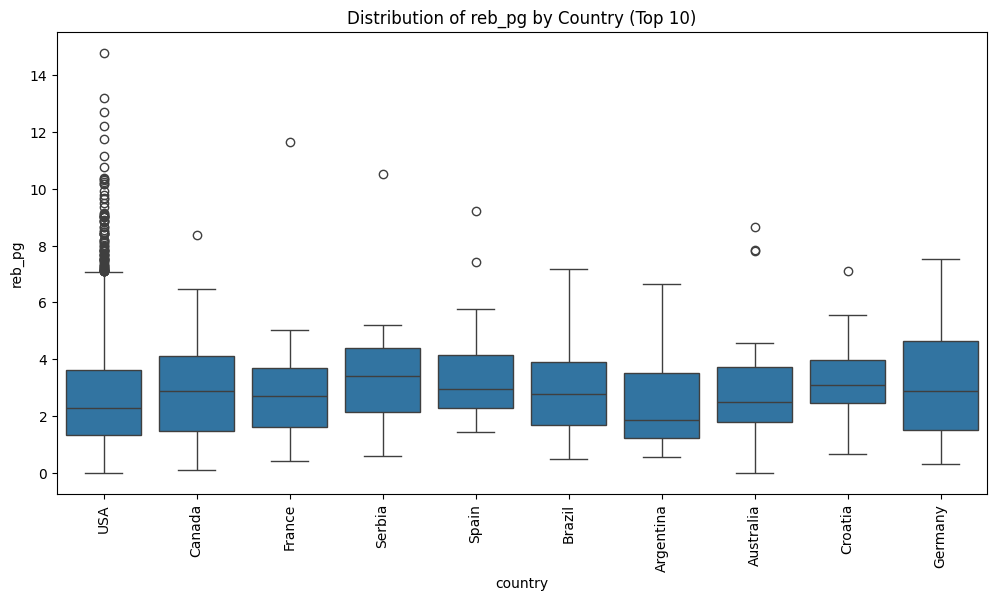

In [97]:
performance_metrics = ['pts_pg', 'ast_pg', 'reb_pg']

top_countries = player_stats['country'].value_counts().head(10).index

filtered_player_stats = player_stats[player_stats['country'].isin(top_countries)]

for metric in performance_metrics:
    data_metric = filtered_player_stats[[metric, 'country']]

    print(f"Shapiro-Wilk Test for Normality ({metric}):")
    for country in top_countries:
        country_data = data_metric[data_metric['country'] == country][metric]
        stat, p = shapiro(country_data)
        print(f"  {country}: Statistics={stat:.3f}, p={p:.3f}")
    print("\n")

    print(f"Levene's Test for Homogeneity of Variances ({metric}):")
    if len(top_countries) >= 2:
        groups = [data_metric[data_metric['country'] == country][metric] for country in top_countries]
        stat, p = levene(*groups)
    else:
        stat, p = float('nan'), float('nan')
    print(f"  Statistics={stat:.3f}, p={p:.3f}")
    print("\n")

    if p > 0.05 and all(shapiro(data_metric[data_metric['country'] == country][metric])[1] > 0.05 for country in top_countries):
        print(f"Performing ANOVA for {metric}:")
        model = sm.ols(f'{metric} ~ C(country)', data=filtered_player_stats).fit()
        anova_table = smsa.anova_lm(model, typ=2)
        print(anova_table)
        print("\n")

        for country1 in top_countries:
            for country2 in top_countries:
                if country1 != country2:
                    cohens_d = pg.compute_effsize(filtered_player_stats[filtered_player_stats['country'] == country1][metric],
                                                filtered_player_stats[filtered_player_stats['country'] == country2][metric],
                                                effsize='cohen')
                    print(f"Cohen's d for {country1} vs. {country2}: {cohens_d:.3f}")

    else:
        print(f"Performing Kruskal-Wallis test for {metric}:")
        h_statistic, p_value = kruskal(*[data_metric[data_metric['country'] == country][metric] for country in top_countries])
        print(f"H-statistic: {h_statistic:.3f}, p-value: {p_value:.3f}")
        print("\n")

        eta_squared = h_statistic / (len(filtered_player_stats) - 1)
        print(f"Eta-squared for {metric}: {eta_squared:.3f}")

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='country', y=metric, data=filtered_player_stats)
    plt.title(f'Distribution of {metric} by Country (Top 10)')
    plt.xticks(rotation=90)
    plt.show()

Points:
There is no significant difference in points per game (p=0.248) or variance (p=0.596) between nationalities. Nationality has a negligible effect on points (eta-squared = 0.005).

Assists:
No significant difference in assists per game (p=0.217) or variance (p=0.111) between nationalities. Nationality has a minimal impact on assists (eta-squared = 0.005).

Rebounds:
No significant difference in rebounds per game (p=0.184) or variance (p=0.991) between nationalities. Nationality explains very little of the variability in rebounds (eta-squared = 0.005).

There is **no significant difference** in points, assists, or rebounds per game between players from different countries, with nationality explaining only a minimal amount of the variability in these performance metrics.

#Which players significantly outperformed/underperformed relative to their draft position?

Regression for pts_pg:
                            OLS Regression Results                            
Dep. Variable:                 pts_pg   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     535.8
Date:                Wed, 21 Jan 2026   Prob (F-statistic):          1.17e-103
Time:                        16:35:58   Log-Likelihood:                -5096.7
No. Observations:                1755   AIC:                         1.020e+04
Df Residuals:                    1753   BIC:                         1.021e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       10.9878  

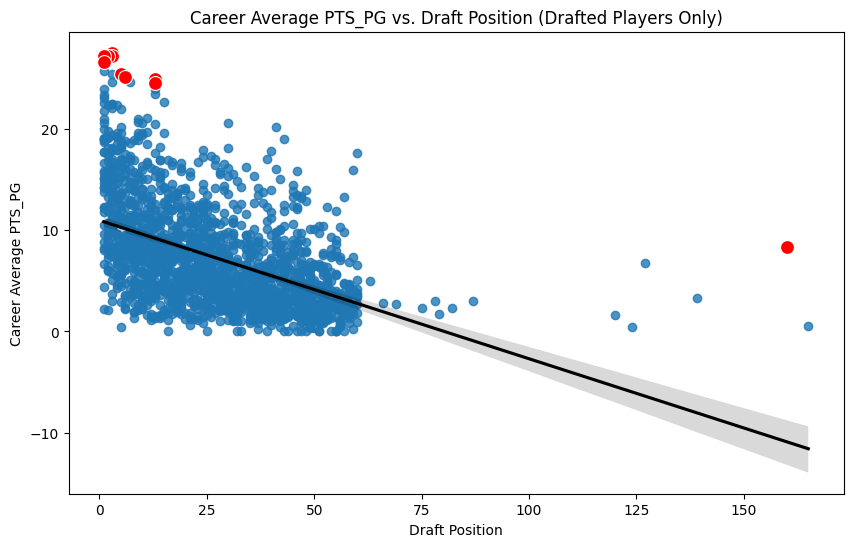

Outliers for pts_pg:
           player_name     pts_pg  predicted_pts_pg  residuals_pts_pg
1644        Mario Elie   8.328696        -10.913905         19.242600
1573       Luka Doncic  27.563030         10.577160         16.985870
1240       Joel Embiid  27.210152         10.577160         16.632992
1433      Kevin Durant  27.272211         10.714046         16.558165
1532      LeBron James  27.197889         10.850932         16.346957
70       Allen Iverson  26.673523         10.850932         15.822591
1470       Kobe Bryant  24.987593          9.208303         15.779290
693   Donovan Mitchell  24.617433          9.208303         15.409131
2359        Trae Young  25.461756         10.303389         15.158368
494     Damian Lillard  25.209103         10.166503         15.042600


Regression for ast_pg:
                            OLS Regression Results                            
Dep. Variable:                 ast_pg   R-squared:                       0.094
Model:                    

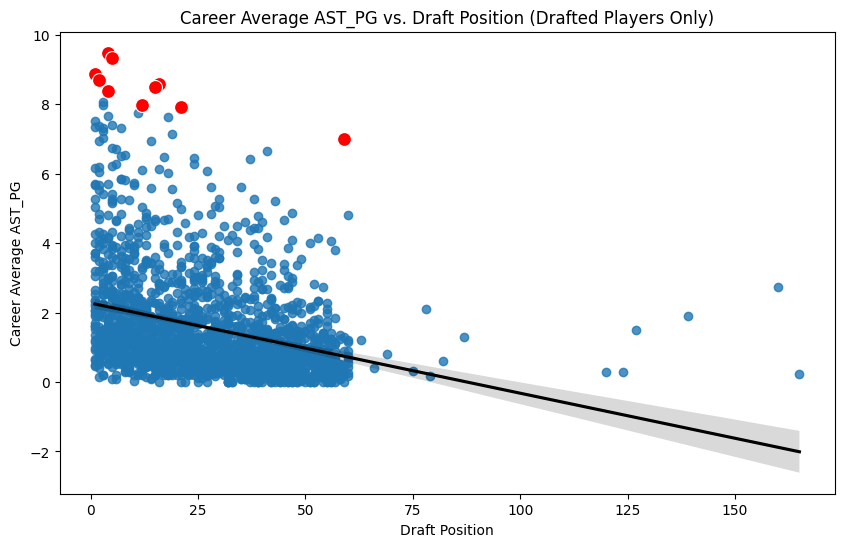

Outliers for ast_pg:
            player_name    ast_pg  predicted_ast_pg  residuals_ast_pg
407          Chris Paul  9.479736          2.167497          7.312240
2359         Trae Young  9.314731          2.141557          7.173174
1263      John Stockton  8.592366          1.856216          6.736151
2245         Steve Nash  8.493919          1.882156          6.611764
1265          John Wall  8.855487          2.245317          6.610170
1129         Jason Kidd  8.708367          2.219377          6.488990
1981       RaiQuan Gray  7.000000          0.740793          6.259207
2101  Russell Westbrook  8.379068          2.167497          6.211571
1983        Rajon Rondo  7.929885          1.726516          6.203369
2421  Tyrese Haliburton  7.964398          1.959976          6.004422


Regression for reb_pg:
                            OLS Regression Results                            
Dep. Variable:                 reb_pg   R-squared:                       0.176
Model:                    

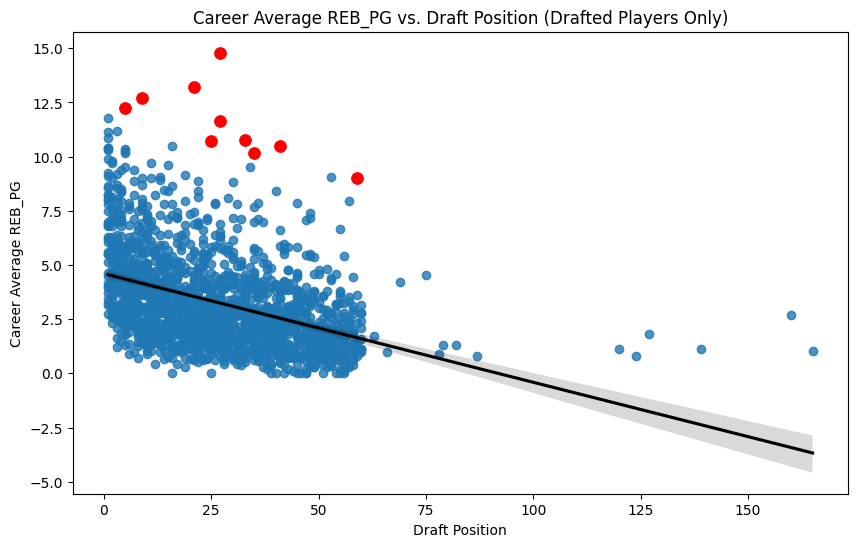

Outliers for reb_pg:
           player_name     reb_pg  predicted_reb_pg  residuals_reb_pg
611      Dennis Rodman  14.792353          3.247036         11.545317
1158   Jayson Williams  13.216912          3.547955          9.668957
93      Andre Drummond  12.698981          4.149792          8.549189
2097       Rudy Gobert  11.663142          3.247036          8.416107
1854      Nikola Jokic  10.508389          2.544892          7.963498
352    Charles Barkley  12.227869          4.350405          7.877464
933   Hassan Whiteside  10.783562          2.946117          7.837445
435       Clint Capela  10.709142          3.347342          7.361800
1981      RaiQuan Gray   9.000000          1.642135          7.357865
578     DeAndre Jordan  10.163788          2.845811          7.317977




In [98]:
filtered_player_stats = player_stats[player_stats['draft_number'] != 0]

performance_metrics = ['pts_pg', 'ast_pg', 'reb_pg']

for metric in performance_metrics:
    model = smf.ols(f'{metric} ~ draft_number', data=filtered_player_stats).fit()
    print(f"Regression for {metric}:")
    print(model.summary())
    print("\n")

    filtered_player_stats[f'predicted_{metric}'] = model.predict(filtered_player_stats['draft_number'])
    filtered_player_stats[f'residuals_{metric}'] = filtered_player_stats[metric] - filtered_player_stats[f'predicted_{metric}']

    outliers = filtered_player_stats.sort_values(by=f'residuals_{metric}', key=abs, ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.regplot(x='draft_number', y=metric, data=filtered_player_stats, line_kws={'color': 'black'})
    sns.scatterplot(x='draft_number', y=metric, data=outliers, color='red', s=100)
    plt.title(f'Career Average {metric.upper()} vs. Draft Position (Drafted Players Only)')
    plt.xlabel('Draft Position')
    plt.ylabel(f'Career Average {metric.upper()}')
    plt.show()

    print(f"Outliers for {metric}:")
    print(outliers[['player_name', metric, f'predicted_{metric}', f'residuals_{metric}']])
    print("\n")

Observing the results, most outliers are players selected early in the draft with above-average performance, but there are also some players selected relatively late who had above-average results:

Mario Elie: 8.32pts, 160th pick

RaiQuan Gray: 7 assists, 9 rebounds, 59th pick

Nikola Jokić: 10.5 rebounds, 41st pick

#Can we predict if player will play 10+ seasons?

Can we predict based on a player's first three seasons whether they will play for more than 10 years?

RandomForestClassifier(max_depth=8, min_samples_split=4, n_estimators=50,
                       random_state=42)
Accuracy: 0.6486
Precision: 0.4065
Recall: 0.5747
F1-score: 0.4762


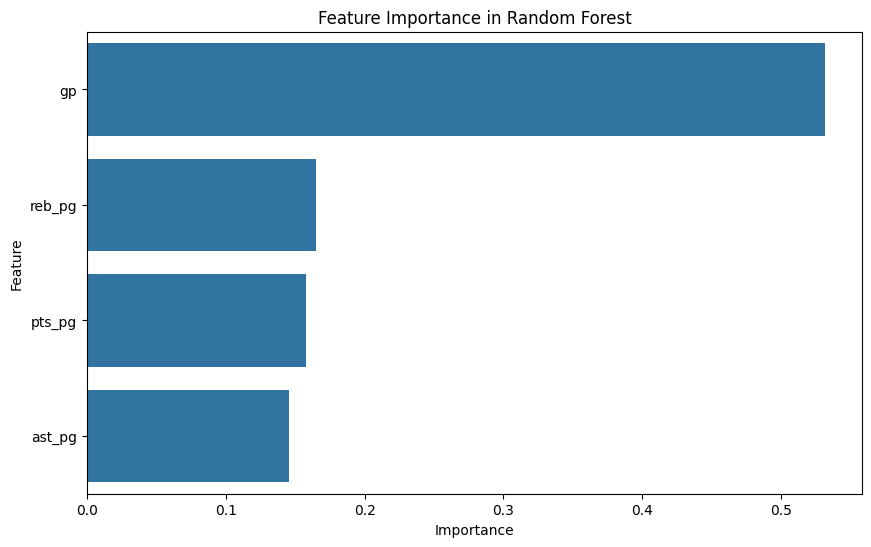

In [99]:
most_recent_season = data['season'].max()

# Corrected: player_stats contains 'last_season', not 'season'
player_stats['career_end'] = player_stats['last_season']
retired_players = player_stats[player_stats['career_end'] < most_recent_season]

player_season_counts = data.groupby('player_name')['season'].transform('count')
qualified_players = data[player_season_counts >= 3]

early_career_stats = (
    qualified_players.sort_values(by=['player_name', 'season'])
    .groupby('player_name')
    .head(3)
    .groupby('player_name')[['pts', 'reb', 'ast', 'gp']]
    .sum()
    .reset_index()
)

for stat in ['pts', 'reb', 'ast']:
    early_career_stats[f"{stat}_pg"] = early_career_stats[stat] / early_career_stats['gp']

total_seasons_played = data.groupby('player_name')['season'].nunique().reset_index()
total_seasons_played.rename(columns={'season': 'total_seasons'}, inplace=True)

early_career_stats = early_career_stats.merge(total_seasons_played, on='player_name')

early_career_stats['longevity'] = (early_career_stats['total_seasons'] >= 10).astype(int)

features = ['pts_pg', 'reb_pg', 'ast_pg', 'gp']
target = 'longevity'

X = early_career_stats[features]
y = early_career_stats[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

oversampler = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

param_grid = {
    'n_estimators': [20, 50, 100],
    'max_depth': [2, 4, 8],
    'min_samples_split': [2, 4, 8],
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_resampled, y_train_resampled)
best_model = grid_search.best_estimator_

print(best_model)

y_pred = best_model.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

feature_importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance in Random Forest')
plt.show()

The model's performance metrics show an F1-score of 0.4762, suggesting room for improvement, though it captures some predictive power regarding player longevity.

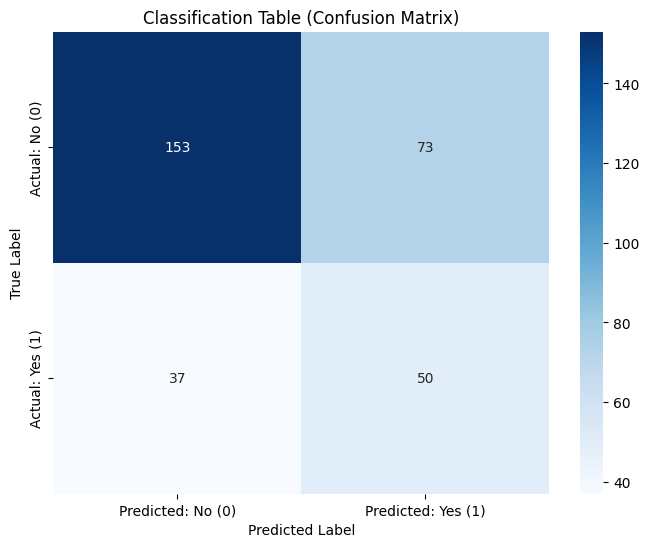

In [100]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No (0)', 'Predicted: Yes (1)'],
            yticklabels=['Actual: No (0)', 'Actual: Yes (1)'])
plt.title('Classification Table (Confusion Matrix)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The model we created can somewhat predict whether a player will play for over 10 years. The most important factor is the number of games played in the first three seasons, which makes sense, as a player who plays a large number of games is likely to continue playing.

However, the model can't provide perfect results, as many factors can impact the remaining 7 years: injuries, changes in team dynamics, coaching strategies, personal development, or unforeseen career shifts that are not captured by the available data. These variables, often unpredictable, can significantly alter a player's longevity, making it challenging for the model to predict with complete accuracy.

##Can we compare the performances of two players throughout their careers?

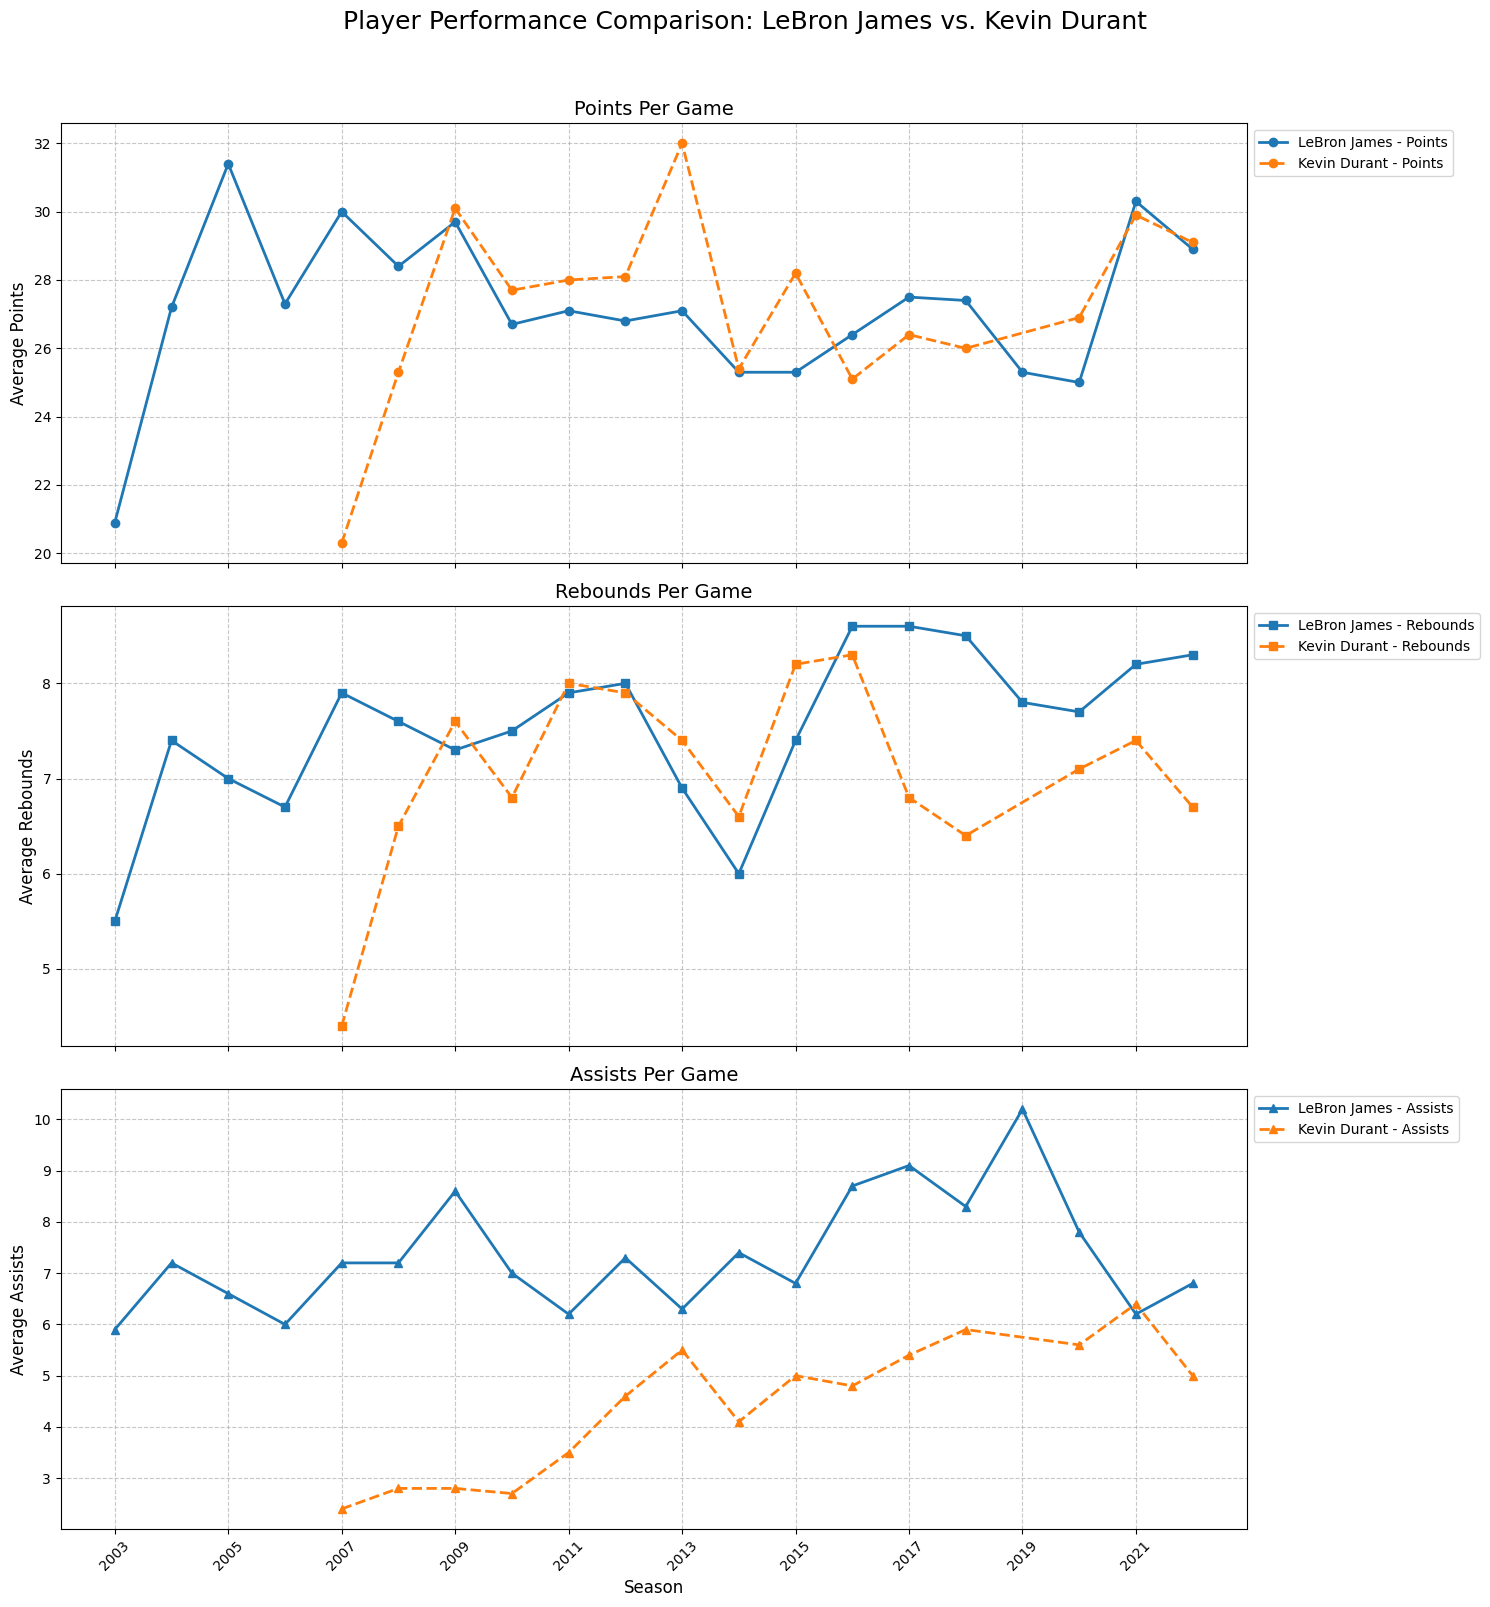

In [101]:
# Define the two players to compare
player_name1 = 'LeBron James'
player_name2 = 'Kevin Durant'

# Get data for Player 1
player_data1 = data[data['player_name'] == player_name1]
player_by_season1 = player_data1.groupby('season').agg({'pts': 'mean','reb': 'mean','ast': 'mean'}).reset_index()

# Get data for Player 2
player_data2 = data[data['player_name'] == player_name2]
player_by_season2 = player_data2.groupby('season').agg({'pts': 'mean','reb': 'mean','ast': 'mean'}).reset_index()

# Determine the min and max season across both players for consistent x-axis ticks
min_season = min(player_by_season1['season'].min(), player_by_season2['season'].min())
max_season = max(player_by_season1['season'].max(), player_by_season2['season'].max())

# Create a figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)
fig.suptitle(f'Player Performance Comparison: {player_name1} vs. {player_name2}', fontsize=18, y=0.92)

# Plot Points
axes[0].plot(player_by_season1['season'], player_by_season1['pts'], marker='o', linestyle='-', linewidth=2, label=f'{player_name1} - Points')
axes[0].plot(player_by_season2['season'], player_by_season2['pts'], marker='o', linestyle='--', linewidth=2, label=f'{player_name2} - Points')
axes[0].set_ylabel('Average Points', fontsize=12)
axes[0].set_title('Points Per Game', fontsize=14)
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Rebounds
axes[1].plot(player_by_season1['season'], player_by_season1['reb'], marker='s', linestyle='-', linewidth=2, label=f'{player_name1} - Rebounds')
axes[1].plot(player_by_season2['season'], player_by_season2['reb'], marker='s', linestyle='--', linewidth=2, label=f'{player_name2} - Rebounds')
axes[1].set_ylabel('Average Rebounds', fontsize=12)
axes[1].set_title('Rebounds Per Game', fontsize=14)
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot Assists
axes[2].plot(player_by_season1['season'], player_by_season1['ast'], marker='^', linestyle='-', linewidth=2, label=f'{player_name1} - Assists')
axes[2].plot(player_by_season2['season'], player_by_season2['ast'], marker='^', linestyle='--', linewidth=2, label=f'{player_name2} - Assists')
axes[2].set_ylabel('Average Assists', fontsize=12)
axes[2].set_title('Assists Per Game', fontsize=14)
axes[2].set_xlabel('Season', fontsize=12)
axes[2].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[2].grid(True, linestyle='--', alpha=0.7)

# Set x-axis ticks to show every 2 years
plt.xticks(np.arange(min_season, max_season + 1, 2), rotation=45) # Rotate x-axis labels once for all subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent suptitle overlap
plt.show()

For most of his career, Kevin Durant was slightly better as a scorer, but Lebron James was significantly better in rebounds and especially assists.

##Can we compare the performances of two teams over the last 25 years?

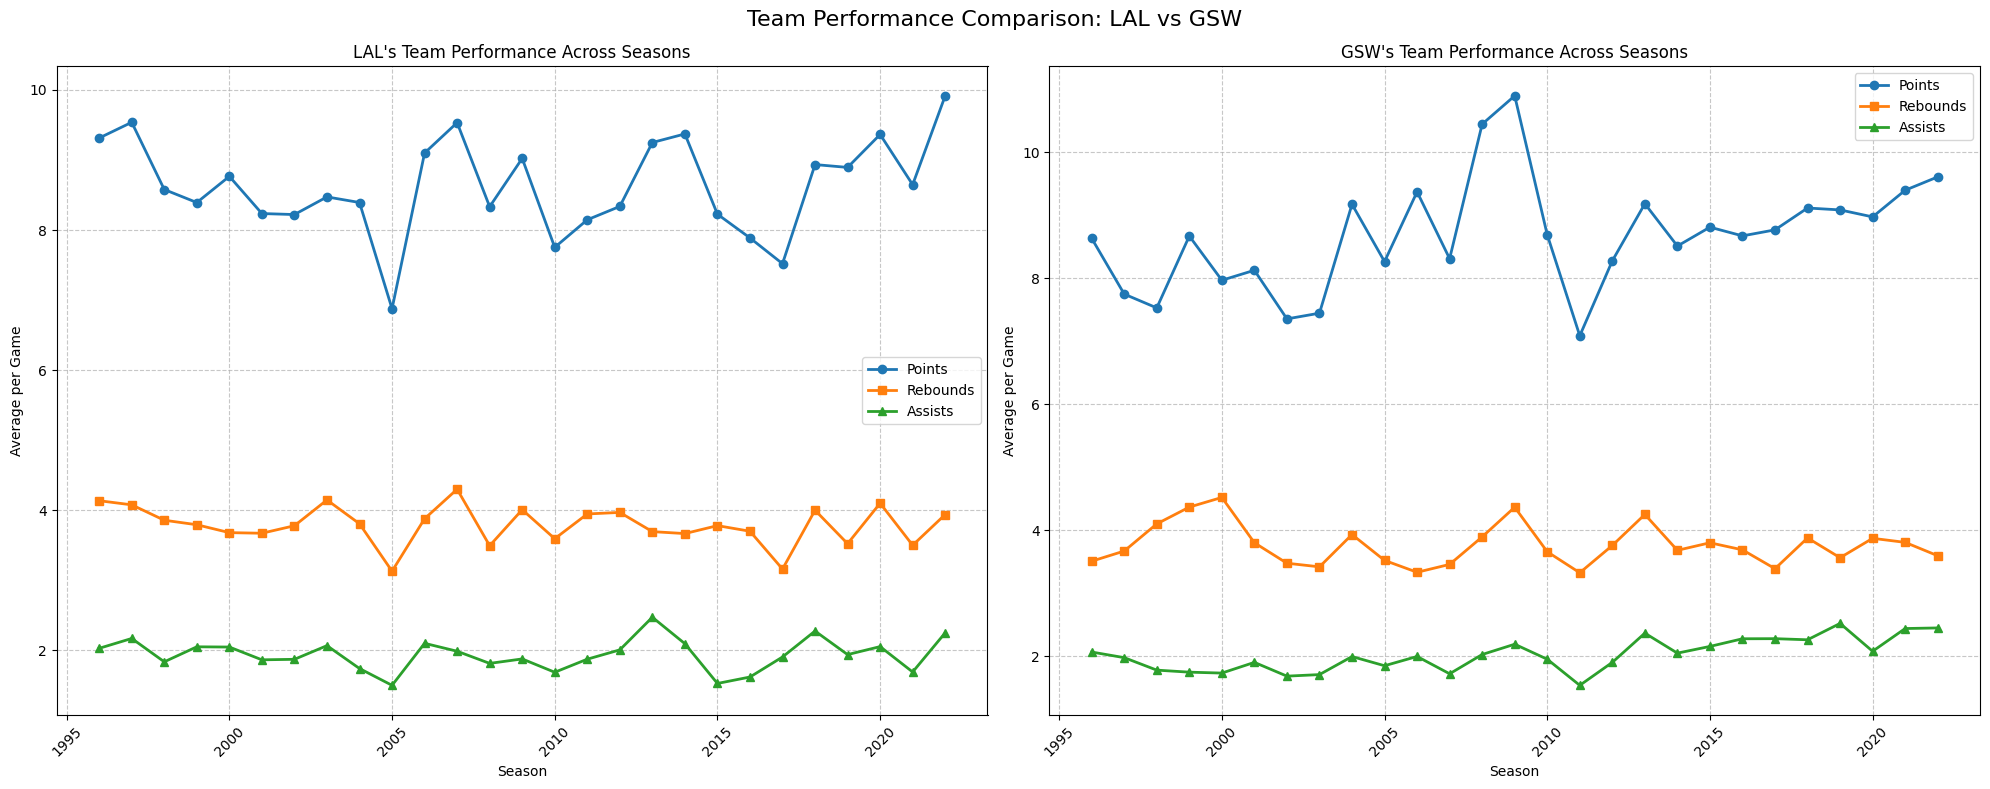

In [102]:
team_abbr1 = 'LAL'  # Los Angeles Lakers
team_abbr2 = 'GSW'  # Golden State Warriors

# Set up the figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Team 1 data and plot
team_data1 = data[data['team_abbreviation'] == team_abbr1]
team_by_season1 = team_data1.groupby('season').agg({
    'pts': 'mean',
    'reb': 'mean',
    'ast': 'mean',
    'ts_pct': 'mean'
}).reset_index()

axes[0].plot(team_by_season1['season'], team_by_season1['pts'], marker='o', linewidth=2, label='Points')
axes[0].plot(team_by_season1['season'], team_by_season1['reb'], marker='s', linewidth=2, label='Rebounds')
axes[0].plot(team_by_season1['season'], team_by_season1['ast'], marker='^', linewidth=2, label='Assists')
axes[0].set_title(f"{team_abbr1}'s Team Performance Across Seasons")
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average per Game')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)

# Team 2 data and plot
team_data2 = data[data['team_abbreviation'] == team_abbr2]
team_by_season2 = team_data2.groupby('season').agg({
    'pts': 'mean',
    'reb': 'mean',
    'ast': 'mean',
    'ts_pct': 'mean'
}).reset_index()

axes[1].plot(team_by_season2['season'], team_by_season2['pts'], marker='o', linewidth=2, label='Points')
axes[1].plot(team_by_season2['season'], team_by_season2['reb'], marker='s', linewidth=2, label='Rebounds')
axes[1].plot(team_by_season2['season'], team_by_season2['ast'], marker='^', linewidth=2, label='Assists')
axes[1].set_title(f"{team_abbr2}'s Team Performance Across Seasons")
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average per Game')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)

# Add a main title for the entire figure
plt.suptitle(f"Team Performance Comparison: {team_abbr1} vs {team_abbr2}", fontsize=16, y=0.98)

plt.tight_layout()
plt.show()

Both teams have had fluctuating performances in terms of points, rebounds, and assists over the years. While LAL saw a dip in performance around the mid-2000s, GSW has shown consistent growth in all metrics, especially in the recent decade.

##Most dominant players

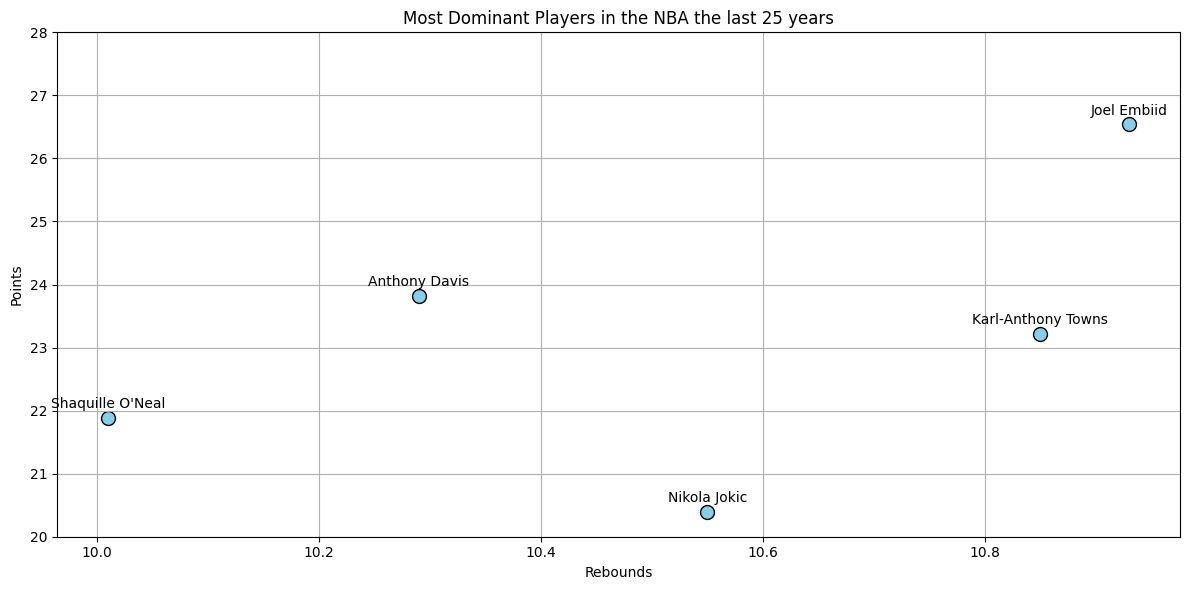

,player_name,pts,reb,ast,draft_number
1240,Joel Embiid,26.54,10.93,3.31,3.0
129,Anthony Davis,23.82,10.29,2.45,1.0
1379,Karl-Anthony Towns,23.22,10.85,3.48,1.0
2187,Shaquille O'Neal,21.88,10.01,2.42,1.0
1854,Nikola Jokic,20.40,10.55,6.71,41.0


In [103]:
player_career_stats = data.groupby('player_name', as_index=False).mean(numeric_only=True).round(2)
dom = player_career_stats[(player_career_stats['pts'] > 20) & (player_career_stats['reb'] > 10)].sort_values(by = 'pts', ascending = False)

plt.figure(figsize = (12,6))
plt.scatter(dom['reb'],dom['pts'], s = 100, color='skyblue', edgecolors='black')
for i, player in enumerate(dom['player_name']):
    plt.annotate(player, (dom['reb'].iloc[i], dom['pts'].iloc[i]),
                 textcoords="offset points", xytext=(0, 7), ha='center')

plt.xlabel('Rebounds')
plt.ylabel('Points')
plt.title('Most Dominant Players in the NBA the last 25 years')
plt.grid(True)
plt.ylim(20, 28)
plt.tight_layout()
plt.show()

dom[['player_name','pts','reb','ast','draft_number']]

##Best playmakers

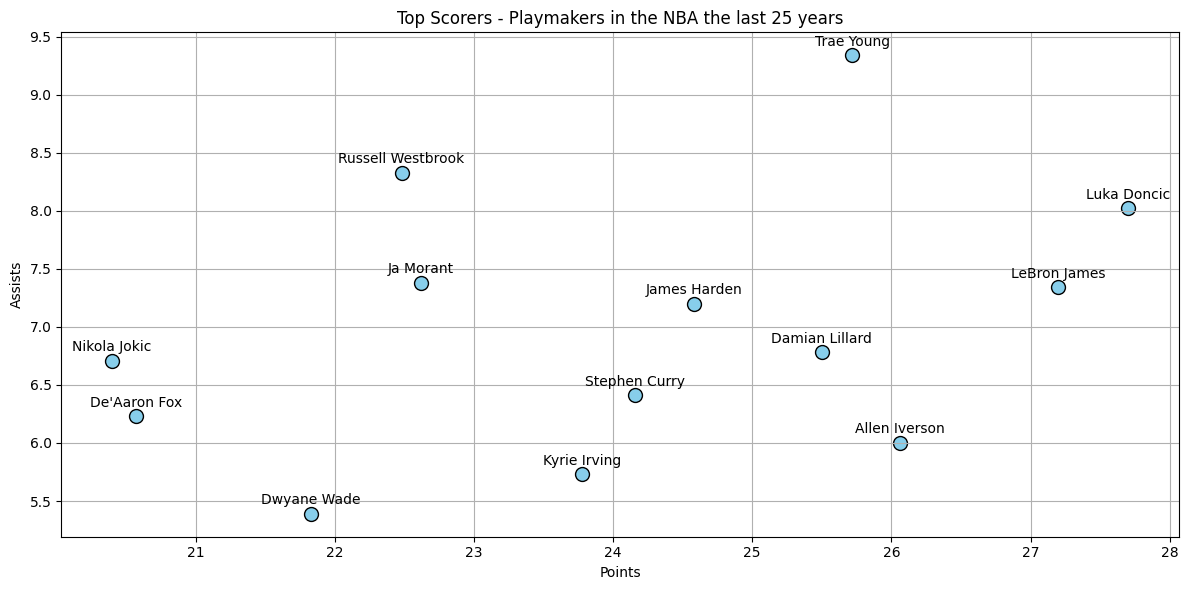

,pts,ast,draft_number
player_name,,,
Luka Doncic,27.70,8.02,3.0
LeBron James,27.20,7.34,1.0
Allen Iverson,26.06,6.00,1.0
Trae Young,25.72,9.34,5.0
Damian Lillard,25.50,6.78,6.0
James Harden,24.58,7.20,3.0
Stephen Curry,24.16,6.41,7.0
Kyrie Irving,23.78,5.73,1.0
Ja Morant,22.62,7.38,2.0


In [104]:
scor_pass = player_career_stats[(player_career_stats['pts'] > 20) & (player_career_stats['ast'] > 5)]

plt.figure(figsize = (12,6))
plt.scatter(x = scor_pass['pts'],y = scor_pass['ast'], s = 100, color='skyblue', edgecolors='black')
for i, player in enumerate(scor_pass['player_name']):
    plt.annotate(player, (scor_pass['pts'].iloc[i], scor_pass['ast'].iloc[i]),
                 textcoords="offset points", xytext=(0, 7), ha='center')

plt.xlabel('Points')
plt.ylabel('Assists')
plt.title('Top Scorers - Playmakers in the NBA the last 25 years')
plt.grid(True)
plt.tight_layout()
plt.show()

scor_pass[['player_name', 'pts', 'ast', 'draft_number']].sort_values(by=['pts','ast'], ascending=False).set_index('player_name')

##Animated graph example - Lebron James

In [105]:
player_to_animate = 'LeBron James'

# Filter data for the chosen player
player_data = data[data['player_name'] == player_to_animate].sort_values('season')

# Ensure 'season' is numerical and suitable for animation
player_data['season_str'] = player_data['season'].astype(str)

# Create the animated scatter plot
fig = px.scatter(
    player_data,
    x='pts',
    y='ast',
    animation_frame='season_str',
    animation_group='player_name',
    size='reb',
    color='team_abbreviation', # Color by team to see team changes
    hover_name='season_str',
    log_x=False,
    size_max=30,
    range_x=[player_data['pts'].min() - 5, player_data['pts'].max() + 5],
    range_y=[player_data['ast'].min() - 2, player_data['ast'].max() + 2],
    title=f'Animated Career Performance for {player_to_animate} (Pts vs Ast over Seasons)'
)

# Customize the animation speed
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 500
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 300

fig.show()